# CF metagenome activity classifier

Apply the saved figure_s15 **Caudoviricetes** inactive/uninducible RandomForest to CF metagenomes
(single libraries; no bulk/enriched pairing).

**Environment:** `lgonsa` micromamba  
`micromamba activate lgonsa`  
Path: `/mmfs1/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa`

**Call rule:** `P(inactive) ≥ meta["thresh_90"]` (currently **0.89**)

Outputs → `cf_activity_results/`


In [1]:
### packages + paths
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

plt.rcParams.update({"font.size": 12})

FIG_5 = Path.cwd().resolve()
if FIG_5.name != "figure_5":
    # Allow running from repo root or manuscript root
    cand = FIG_5 / "uhvdb-manuscript" / "figure_5"
    if cand.is_dir():
        FIG_5 = cand
    elif (FIG_5 / "figure_5").is_dir():
        FIG_5 = FIG_5 / "figure_5"

FIG_S15 = FIG_5.parent / "figure_s15"
sys.path.insert(0, str(FIG_S15))

from _he6_analysis_core import (  # noqa: E402
    GENE_BREADTH_THRESHOLD,
    GENE_PROP_COLS,
    GENE_STAT_COLS,
    META_HALLMARK_COLLISION_COLS,
    PROF_FEAT_COLS,
    _parse_ani_width,
    _parse_containment_frac,
    gene_prop_agg,
    load_depth,
)

MODEL_DIR = FIG_S15
METADATA = FIG_5.parent / "figure_s18" / "uhvdb_v5_final_metadata_v2.tsv.gz"
REF_ANALYZE = (
    FIG_5
    / "cf_metag_results"
    / "2026-04-08_outputs"
    / "referenceanalyze"
)
COVERM_AGG = FIG_5 / "cf_metag_coverm_results.tsv.gz"
SYLPH_GLOB = REF_ANALYZE / "sylph" / "*" / "*.profile.tsv.gz"
GENE_GLOB = REF_ANALYZE / "coverm" / "*" / "bam" / "*.gene_coverage.tsv.gz"
OUT_DIR = FIG_5 / "cf_activity_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

GENE_CHUNK_SIZE = 200

print("FIG_5:", FIG_5)
print("MODEL_DIR:", MODEL_DIR)
print("OUT_DIR:", OUT_DIR)


FIG_5: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5
MODEL_DIR: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_s15
OUT_DIR: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results


In [2]:
### load saved classifier
meta = joblib.load(MODEL_DIR / "phage_model_metadata_full.joblib")
pipeline = joblib.load(MODEL_DIR / "phage_activity_model_full.joblib")
numeric_cols = list(meta["numeric_cols"])
thr = float(meta["thresh_90"])
ictv_class_filter = meta.get("ictv_class_filter", "Caudoviricetes")
if ictv_class_filter != "Caudoviricetes":
    raise ValueError(
        f"Expected Caudoviricetes model; got ictv_class_filter={ictv_class_filter!r}"
    )

print(
    f"features={len(numeric_cols)}  thresh_90={thr:.4f}  "
    f"ictv_class_filter={ictv_class_filter}"
)


features=86  thresh_90=0.8900  ictv_class_filter=Caudoviricetes


In [3]:
### UHVDB metadata → id_map + static species features
uhvdb_cols = pl.read_csv(METADATA, separator="\t", n_rows=0).columns
uhvdb_full = pl.read_csv(METADATA, separator="\t")

# Drop RNA / reverse-transcribing ICTV classes (Riboviria: Orthornavirae + Pararnavirae).
# DNA classes (Caudoviricetes, Microviridae/Inoviridae, CRESS, etc.) are retained.
RNA_ICTV_CLASSES = {
    "Pisoniviricetes",
    "Flasuviricetes",
    "Alsuviricetes",
    "Howeltoviricetes",
    "Stelpaviricetes",
    "Miaviricetes",
    "Amabiliviricetes",
    "Leviviricetes",
    "Magsaviricetes",
    "Tolucaviricetes",
    "Monjiviricetes",
    "Chrymotiviricetes",
    "Revtraviricetes",
}
_n_meta_before = uhvdb_full.height
uhvdb_full = uhvdb_full.filter(
    pl.col("ictv_class").is_null() | ~pl.col("ictv_class").is_in(list(RNA_ICTV_CLASSES))
)
print(
    f"Removed RNA/RT ICTV classes from metadata: {_n_meta_before:,} -> {uhvdb_full.height:,} "
    f"({_n_meta_before - uhvdb_full.height:,} genomes excluded)"
)
print(
    "Excluded classes:",
    ", ".join(sorted(RNA_ICTV_CLASSES)),
)
uhvdb = uhvdb_full.drop([c for c in META_HALLMARK_COLLISION_COLS if c in uhvdb_cols])

id_map = (
    uhvdb_full.select(["uhvdb_id", "species_cluster_id"])
    .unique("uhvdb_id")
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
)

_quality = (
    uhvdb_full.with_columns(pl.col("species_cluster_id").cast(pl.Int64))
    .group_by("species_cluster_id")
    .agg(
        [
            (pl.col("checkv_quality") == "Complete").sum().alias("complete_count"),
            (pl.col("checkv_quality") == "High-quality").sum().alias("high_quality_count"),
        ]
    )
)

_sp_meta_agg = uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep")).with_columns(
    pl.col("species_cluster_id").cast(pl.Int64)
)
_meta_sp = (
    _sp_meta_agg.unique("species_cluster_id", keep="first")
    .with_columns(
        [
            pl.col("virulent").alias("annot_virulent"),
            pl.col("virulent").alias("med_virulent_score"),
            pl.col("temperate"),
            pl.col("phrog_integrases").cast(pl.Float64),
            pl.col("phrog_integration_excision").cast(pl.Float64),
            pl.col("empathi_integration").cast(pl.Float64),
            (pl.col("integration_status") == "integrated")
            .cast(pl.Float64)
            .alias("is_integrated"),
            (
                pl.col("provirus")
                .cast(pl.Utf8)
                .str.to_lowercase()
                .is_in(["yes", "true", "1"])
            )
            .cast(pl.Float64)
            .alias("is_provirus"),
            pl.col("num_lysis").cast(pl.Float64),
            pl.col("num_tail").cast(pl.Float64),
            pl.col("num_capsid").cast(pl.Float64),
            pl.col("num_proteins").cast(pl.Float64),
            pl.col("mcp_hallmark").cast(pl.Float64).alias("annot_mcp_hallmark"),
            pl.col("terl_hallmark").cast(pl.Float64).alias("annot_terl_hallmark"),
            pl.col("portal_hallmark").cast(pl.Float64).alias("annot_portal_hallmark"),
            pl.col("n_hallmarks").cast(pl.Float64).alias("annot_n_hallmarks"),
            pl.col("virus_hallmarks").cast(pl.Float64),
            pl.col("aai_id").alias("annot_aai_id"),
            pl.col("aai_af").alias("annot_aai_af"),
            ((pl.col("aai_id") / 100) * pl.col("aai_af")).alias("med_aai_id_af"),
            pl.col("aai_completeness"),
            pl.when(pl.col("aai_confidence") == "low")
            .then(0.0)
            .when(pl.col("aai_confidence") == "medium")
            .then(1.0)
            .when(pl.col("aai_confidence") == "high")
            .then(2.0)
            .otherwise(1.0)
            .alias("aai_confidence_ord"),
            pl.col("Score"),
            pl.col("kmer_freq"),
            pl.col("completeness"),
            pl.col("virus_score"),
            pl.col("host_genes"),
            pl.col("viral_genes"),
            pl.col("contig_length"),
            pl.col("n_genes"),
            pl.col("ictv_class"),
            pl.col("topology")
            .is_in(["DTR", "ITR"])
            .cast(pl.Float64)
            .alias("has_terminal_repeats"),
            (pl.col("topology") == "DTR").cast(pl.Float64).alias("is_DTR"),
            (pl.col("topology") == "ITR").cast(pl.Float64).alias("is_ITR"),
            (pl.col("topology") == "Provirus")
            .cast(pl.Float64)
            .alias("is_topology_provirus"),
            (
                pl.col("proviral_length")
                .cast(pl.Utf8)
                .replace("NA", None)
                .cast(pl.Float64, strict=False)
                / pl.col("contig_length")
            ).alias("proviral_frac"),
            pl.col("completeness_method")
            .cast(pl.Utf8)
            .str.contains("DTR")
            .cast(pl.Float64)
            .alias("cm_dtr"),
        ]
    )
    .with_columns(
        [
            (pl.col("num_lysis") / (pl.col("contig_length") / 1000)).alias("num_lysis_per_kb"),
            (pl.col("num_tail") / (pl.col("contig_length") / 1000)).alias("num_tail_per_kb"),
            (pl.col("num_capsid") / (pl.col("contig_length") / 1000)).alias("num_capsid_per_kb"),
            (pl.col("num_proteins") / (pl.col("contig_length") / 1000)).alias(
                "num_proteins_per_kb"
            ),
            (pl.col("phrog_integrases") / (pl.col("contig_length") / 1000)).alias(
                "phrog_integrases_per_kb"
            ),
            (pl.col("phrog_integration_excision") / (pl.col("contig_length") / 1000)).alias(
                "phrog_integration_excision_per_kb"
            ),
            (pl.col("empathi_integration") / (pl.col("contig_length") / 1000)).alias(
                "empathi_integration_per_kb"
            ),
            (pl.col("annot_n_hallmarks") / (pl.col("contig_length") / 1000)).alias(
                "annot_n_hallmarks_per_kb"
            ),
            (pl.col("virus_hallmarks") / (pl.col("contig_length") / 1000)).alias(
                "virus_hallmarks_per_kb"
            ),
            pl.col("contig_length").log1p().alias("log_contig_length"),
            pl.col("n_genes").log1p().alias("log_n_genes"),
        ]
    )
)

print(
    f"metadata genomes={uhvdb_full.height:,}  species_reps={_meta_sp.height:,}  "
    f"id_map={id_map.height:,}"
)


Removed RNA/RT ICTV classes from metadata: 816,318 -> 815,352 (966 genomes excluded)
Excluded classes: Alsuviricetes, Amabiliviricetes, Chrymotiviricetes, Flasuviricetes, Howeltoviricetes, Leviviricetes, Magsaviricetes, Miaviricetes, Monjiviricetes, Pisoniviricetes, Revtraviricetes, Stelpaviricetes, Tolucaviricetes
metadata genomes=815,352  species_reps=205,737  id_map=616,895


In [4]:
### CoverM (prefer pre-aggregated table from figure_5_prep)
if COVERM_AGG.exists():
    coverm_df = pl.read_csv(COVERM_AGG, separator="\t")
    print(f"Loaded aggregated CoverM: {COVERM_AGG.name}")
else:
    coverm_paths = sorted((REF_ANALYZE / "coverm").glob("*/*.coverm.tsv.gz"))
    coverm_lst = []
    for path in coverm_paths:
        sid = path.name.split(".")[0]
        try:
            coverm_lst.append(load_depth(path, sid))
        except Exception as exc:
            print(f"skip coverm {sid}: {exc}")
    coverm_df = pl.concat(coverm_lst) if coverm_lst else pl.DataFrame()
    print(f"Loaded {len(coverm_paths)} per-sample CoverM files")

print(
    f"coverm rows={coverm_df.height:,}  samples={coverm_df['sample_id'].n_unique():,}"
)

# Restrict CoverM to non-RNA UHVDB genomes (uses uhvdb_full after RNA filter above)
_non_rna_ids = uhvdb_full.select("uhvdb_id").unique()
_n_coverm_before = coverm_df.height
coverm_df = coverm_df.join(
    _non_rna_ids, left_on="contig_id", right_on="uhvdb_id", how="inner"
)
print(
    f"CoverM after removing RNA/RT genomes: {_n_coverm_before:,} -> {coverm_df.height:,} rows "
    f"(samples={coverm_df['sample_id'].n_unique():,})"
)


Loaded aggregated CoverM: cf_metag_coverm_results.tsv.gz
coverm rows=72,431  samples=1,809
CoverM after removing RNA/RT genomes: 72,431 -> 72,020 rows (samples=1,807)


In [5]:
### Sylph profiles → species-level features
sylph_paths = sorted(Path(REF_ANALYZE / "sylph").glob("*/*.profile.tsv.gz"))
print(f"Found {len(sylph_paths)} sylph profile files")

prof_lst = []
for i, path in enumerate(sylph_paths, start=1):
    sid = path.name.replace(".profile.tsv.gz", "")
    try:
        df = (
            pl.read_csv(path, separator="\t")
            .filter(pl.col("Contig_name").str.starts_with("UHVDB-"))
            .with_columns(
                [
                    pl.lit(sid).alias("sample_id"),
                    pl.col("Contig_name").alias("uhvdb_id"),
                    pl.col("True_cov").cast(pl.Float64),
                    pl.col("Taxonomic_abundance").cast(pl.Float64).alias("tax_abund"),
                    pl.col("Sequence_abundance").cast(pl.Float64).alias("seq_abund"),
                    pl.col("Adjusted_ANI").cast(pl.Float64),
                    pl.col("Naive_ANI").cast(pl.Float64),
                    pl.col("Median_cov").cast(pl.Float64),
                    pl.col("Mean_cov_geq1").cast(pl.Float64),
                    pl.col("kmers_reassigned").cast(pl.Float64),
                    pl.col("Containment_ind").cast(pl.Utf8),
                    pl.col("Eff_lambda").cast(pl.Utf8),
                    pl.col("ANI_5-95_percentile").cast(pl.Utf8).alias("ANI_5_95"),
                ]
            )
        )
        if df.height:
            prof_lst.append(df)
    except Exception as exc:
        print(f"skip sylph {sid}: {exc}")

    if i % 250 == 0 or i == len(sylph_paths):
        print(f"  sylph progress {i}/{len(sylph_paths)} kept={len(prof_lst)}")

prof_raw = pl.concat(prof_lst) if prof_lst else pl.DataFrame()
print(f"sylph UHVDB rows={prof_raw.height:,}  samples={prof_raw['sample_id'].n_unique() if prof_raw.height else 0:,}")

_prof_sp = (
    prof_raw.join(id_map, on="uhvdb_id", how="inner")
    .sort(["sample_id", "species_cluster_id", "tax_abund"], descending=[False, False, True])
    .unique(["sample_id", "species_cluster_id"], keep="first")
    .with_columns(
        [
            pl.col("Containment_ind")
            .map_elements(_parse_containment_frac, return_dtype=pl.Float64)
            .alias("containment_frac"),
            (
                pl.when(pl.col("Eff_lambda").cast(pl.Utf8).str.to_uppercase() == "LOW")
                .then(0.0)
                .when(
                    pl.col("Eff_lambda")
                    .cast(pl.Utf8)
                    .str.to_uppercase()
                    .is_in(["MEDIUM", "MED"])
                )
                .then(1.0)
                .when(pl.col("Eff_lambda").cast(pl.Utf8).str.to_uppercase() == "HIGH")
                .then(2.0)
                .otherwise(None)
                .alias("Eff_lambda_ord")
            ),
            pl.col("ANI_5_95")
            .map_elements(_parse_ani_width, return_dtype=pl.Float64)
            .alias("ANI_interval_width"),
            (pl.col("Median_cov") / pl.col("Mean_cov_geq1")).alias("cov_evenness"),
            pl.col("True_cov").log1p().alias("log_True_cov"),
            pl.col("tax_abund").fill_null(0).log1p().alias("log_tax_abund"),
            pl.col("seq_abund").fill_null(0).log1p().alias("log_seq_abund"),
            pl.col("Adjusted_ANI").alias("ani"),
        ]
    )
)
_prof_sp = (
    _prof_sp.with_columns(
        [
            pl.col("True_cov").rank(method="average").over("sample_id").alias("_tc_rank"),
            pl.col("tax_abund").rank(method="average").over("sample_id").alias("_ta_rank"),
            pl.len().over("sample_id").alias("_n_in_sample"),
        ]
    ).with_columns(
        [
            (pl.col("_tc_rank") / pl.col("_n_in_sample")).alias("True_cov_rank"),
            (pl.col("_ta_rank") / pl.col("_n_in_sample")).alias("tax_abund_rank"),
        ]
    )
)
print(f"sylph species-level rows={_prof_sp.height:,}")



Found 1959 sylph profile files
  sylph progress 250/1959 kept=231
  sylph progress 500/1959 kept=393
  sylph progress 750/1959 kept=611
  sylph progress 1000/1959 kept=856
  sylph progress 1250/1959 kept=1103
  sylph progress 1500/1959 kept=1351
  sylph progress 1750/1959 kept=1600
  sylph progress 1959/1959 kept=1809
sylph UHVDB rows=72,431  samples=1,809
sylph species-level rows=72,020


In [6]:
### Gene coverage (chunked) → med_prop_* + gene stats
gene_paths = sorted(Path(REF_ANALYZE / "coverm").glob("*/bam/*.gene_coverage.tsv.gz"))
print(f"Found {len(gene_paths)} gene_coverage files")


def _load_gene_chunk(paths):
    rows = []
    for path in paths:
        sid = path.name.replace(".gene_coverage.tsv.gz", "")
        try:
            df = (
                pl.read_csv(path, separator="\t")
                .filter(pl.col("genomovar_rep").str.starts_with("UHVDB-"))
                .with_columns(pl.lit(sid).alias("sample_id"))
            )
            if df.height:
                rows.append(df)
        except Exception as exc:
            print(f"skip gene {sid}: {exc}")
    return pl.concat(rows) if rows else None


gene_prop_parts = []
gene_stat_parts = []

_struct = (
    (pl.col("pharokka_annot") == "major head protein")
    | (pl.col("phold_category") == "major head protein")
    | (pl.col("empathi_annot") == "pvp|capsid|major_capsid")
    | (pl.col("pharokka_annot") == "terminase large subunit")
    | (pl.col("phold_category") == "terminase large subunit")
    | (pl.col("empathi_annot") == "DNA-associated|terminase|packaging_assembly")
    | (pl.col("pharokka_annot") == "portal protein")
    | (pl.col("phold_category") == "portal protein")
    | (pl.col("empathi_annot") == "pvp|portal")
)

for i in range(0, len(gene_paths), GENE_CHUNK_SIZE):
    chunk_paths = gene_paths[i : i + GENE_CHUNK_SIZE]
    gene_raw = _load_gene_chunk(chunk_paths)
    if gene_raw is None:
        continue

    gene_prop = (
        gene_prop_agg(gene_raw.filter(pl.col("breadth") > GENE_BREADTH_THRESHOLD))
        .join(id_map.rename({"uhvdb_id": "genomovar_rep"}), on="genomovar_rep", how="inner")
        .with_columns(
            [
                pl.col("prop_capsid_packaging").alias("med_prop_capsid_packaging"),
                pl.col("prop_dna_metabolism").alias("med_prop_dna_metabolism"),
                pl.col("prop_tail").alias("med_prop_tail"),
                pl.col("prop_lysis").alias("med_prop_lysis"),
                pl.col("prop_connector").alias("med_prop_connector"),
                pl.col("prop_transcription").alias("med_prop_transcription"),
                pl.col("prop_integration").alias("med_prop_integration"),
                pl.col("prop_amg_host_takeover").alias("med_prop_amg_host_takeover"),
                pl.col("mcp_hallmark").alias("med_mcp_hallmark"),
                pl.col("portal_hallmark").alias("med_portal_hallmark"),
                pl.col("terl_hallmark").alias("med_terL_hallmark"),
                pl.col("n_hallmarks").alias("med_n_hallmarks"),
            ]
        )
        .sort(
            ["sample_id", "species_cluster_id", "n_genes_covered"],
            descending=[False, False, True],
        )
        .unique(["sample_id", "species_cluster_id"], keep="first")
        .select(["sample_id", "species_cluster_id"] + GENE_PROP_COLS)
    )
    gene_prop_parts.append(gene_prop)

    gene_stats = (
        gene_raw.with_columns(_struct.alias("is_struct"))
        .group_by(["sample_id", "genomovar_rep"])
        .agg(
            [
                pl.col("breadth").mean().alias("gene_breadth_mean"),
                pl.col("breadth").std().alias("gene_breadth_std"),
                (pl.col("breadth") >= 0.5).mean().alias("frac_genes_breadth_ge_0_5"),
                (pl.col("breadth") >= 0.8).mean().alias("frac_genes_breadth_ge_0_8"),
                pl.col("mean_depth").mean().alias("gene_mean_depth_mean"),
                pl.col("mean_depth").std().alias("gene_mean_depth_std"),
                pl.col("is_struct").sum().cast(pl.Float64).alias("n_struct_genes"),
                (pl.col("breadth") > GENE_BREADTH_THRESHOLD)
                .sum()
                .cast(pl.Float64)
                .alias("n_genes_covered"),
            ]
        )
        .with_columns(
            (pl.col("gene_breadth_std") / pl.col("gene_breadth_mean")).alias("gene_breadth_cv")
        )
        .join(id_map.rename({"uhvdb_id": "genomovar_rep"}), on="genomovar_rep", how="inner")
        .sort(
            ["sample_id", "species_cluster_id", "n_genes_covered"],
            descending=[False, False, True],
        )
        .unique(["sample_id", "species_cluster_id"], keep="first")
        .join(
            _meta_sp.select(["species_cluster_id", "n_genes"]),
            on="species_cluster_id",
            how="left",
        )
        .with_columns((pl.col("n_genes_covered") / pl.col("n_genes")).alias("gene_occupancy"))
        .select(["sample_id", "species_cluster_id"] + GENE_STAT_COLS)
    )
    gene_stat_parts.append(gene_stats)
    print(
        f"  gene chunk {i // GENE_CHUNK_SIZE + 1}/{(len(gene_paths) + GENE_CHUNK_SIZE - 1) // GENE_CHUNK_SIZE}: "
        f"{len(chunk_paths)} files → prop={gene_prop.height:,} stats={gene_stats.height:,}"
    )

gene_prop_df = pl.concat(gene_prop_parts) if gene_prop_parts else pl.DataFrame()
gene_stats_df = pl.concat(gene_stat_parts) if gene_stat_parts else pl.DataFrame()
print(
    f"gene_prop rows={gene_prop_df.height:,}  gene_stats rows={gene_stats_df.height:,}"
)


Found 1809 gene_coverage files
  gene chunk 1/10: 200 files → prop=3,847 stats=3,912
  gene chunk 2/10: 200 files → prop=3,511 stats=3,609
  gene chunk 3/10: 200 files → prop=5,391 stats=5,516
  gene chunk 4/10: 200 files → prop=5,679 stats=5,783
  gene chunk 5/10: 200 files → prop=8,283 stats=8,400
  gene chunk 6/10: 200 files → prop=7,560 stats=7,610
  gene chunk 7/10: 200 files → prop=21,722 stats=21,823
  gene chunk 8/10: 200 files → prop=9,676 stats=9,837
  gene chunk 9/10: 200 files → prop=5,143 stats=5,385
  gene chunk 10/10: 9 files → prop=137 stats=145
gene_prop rows=70,949  gene_stats rows=72,020


In [7]:
### Assemble Caudoviricetes sample × species feature matrix
# Join only identity/ICTV columns from metadata to avoid colliding with _meta_sp features.
_id_ictv = (
    uhvdb_full.select(
        ["uhvdb_id", "species_cluster_id", "seq_name", "seqhash_rep", "ictv_class"]
    ).with_columns(pl.col("species_cluster_id").cast(pl.Int64))
)

base = (
    coverm_df.filter(pl.col("breadth_ratio") > 0)
    .join(_id_ictv, left_on="contig_id", right_on="uhvdb_id", how="left")
    .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
)

n_before = base.height
ictv_counts = (
    base.group_by("ictv_class").agg(pl.len().alias("n")).sort("n", descending=True)
)
print("ICTV class counts before filter:")
print(ictv_counts.head(10))

base = base.filter(pl.col("ictv_class") == ictv_class_filter)
print(
    f"Restricted to {ictv_class_filter}: {n_before:,} -> {base.height:,} rows "
    f"({base.height / max(n_before, 1):.1%})"
)

# One row per sample × species (prefer highest breadth_ratio contig if duplicates)
base = (
    base.sort(
        ["sample_id", "species_cluster_id", "breadth_ratio"],
        descending=[False, False, True],
    )
    .unique(["sample_id", "species_cluster_id"], keep="first")
    .with_columns(
        pl.when(pl.col("trimmed_mean") > 0)
        .then(pl.col("variance") / pl.col("trimmed_mean"))
        .otherwise(None)
        .alias("variance_ratio")
    )
)

# Static annotation features used by the model (exclude raw metadata extras / ictv_class duplicate)
_meta_feat_cols = [
    c
    for c in _meta_sp.columns
    if c == "species_cluster_id" or c in numeric_cols
]

empty_gene_keys = pl.DataFrame(
    schema={"sample_id": pl.Utf8, "species_cluster_id": pl.Int64}
)

feat = (
    base.join(_quality, on="species_cluster_id", how="left")
    .join(_meta_sp.select(_meta_feat_cols), on="species_cluster_id", how="left")
    .join(
        gene_prop_df if gene_prop_df.height else empty_gene_keys,
        on=["sample_id", "species_cluster_id"],
        how="left",
    )
    .join(
        _prof_sp.select(["sample_id", "species_cluster_id"] + PROF_FEAT_COLS),
        on=["sample_id", "species_cluster_id"],
        how="left",
    )
    .join(
        gene_stats_df if gene_stats_df.height else empty_gene_keys,
        on=["sample_id", "species_cluster_id"],
        how="left",
    )
)

missing = [c for c in numeric_cols if c not in feat.columns]
if missing:
    raise KeyError(f"Missing features: {missing}")

null_frac = float(
    np.mean([feat[c].null_count() / max(feat.height, 1) for c in numeric_cols])
)
print(
    f"feature matrix: n={feat.height:,}  samples={feat['sample_id'].n_unique():,}  "
    f"mean_null_frac={null_frac:.3f}"
)


ICTV class counts before filter:
shape: (10, 2)
┌────────────────────┬───────┐
│ ictv_class         ┆ n     │
│ ---                ┆ ---   │
│ str                ┆ u32   │
╞════════════════════╪═══════╡
│ Caudoviricetes     ┆ 60858 │
│ Faserviricetes     ┆ 8926  │
│ Malgrandaviricetes ┆ 1031  │
│ Arfiviricetes      ┆ 923   │
│ Tectiliviricetes   ┆ 93    │
│ Cardeaviricetes    ┆ 60    │
│ Polintoviricetes   ┆ 19    │
│ Papovaviricetes    ┆ 19    │
│ Pokkesviricetes    ┆ 13    │
│ Herviviricetes     ┆ 6     │
└────────────────────┴───────┘
Restricted to Caudoviricetes: 71,954 -> 60,858 rows (84.6%)
feature matrix: n=60,855  samples=1,777  mean_null_frac=0.035


In [8]:
### Score classifier
scored = feat.to_pandas()
X = scored.reindex(columns=numeric_cols)
proba = pipeline.predict_proba(X)[:, 1]
scored["predicted_inactive_probability"] = proba
scored["predicted_uninducible"] = (proba >= thr).astype(int)

n_called = int(scored["predicted_uninducible"].sum())
print(
    f"Scored {len(scored):,} rows across {scored['sample_id'].nunique():,} samples; "
    f"predicted_uninducible={n_called:,} ({n_called / max(len(scored), 1):.1%}) "
    f"at p≥{thr:.2f}"
)


Scored 60,855 rows across 1,777 samples; predicted_uninducible=17,391 (28.6%) at p≥0.89


In [9]:
### Write outputs
pred_cols = [
    "sample_id",
    "group",
    "species_cluster_id",
    "contig_id",
    "ictv_class",
    "breadth",
    "breadth_ratio",
    "variance_ratio",
    "trimmed_mean",
    "mean",
    "ani",
    "log_True_cov",
    "log_tax_abund",
    "predicted_inactive_probability",
    "predicted_uninducible",
]
pred_cols = [c for c in pred_cols if c in scored.columns]
pred_out = scored[pred_cols].copy()

feat_out_cols = [
    "sample_id",
    "group",
    "species_cluster_id",
    "contig_id",
    "ictv_class",
    "predicted_inactive_probability",
    "predicted_uninducible",
] + numeric_cols
feat_out_cols = [c for c in feat_out_cols if c in scored.columns]
feat_out = scored[feat_out_cols].copy()

pred_path = OUT_DIR / "cf_caudoviricetes_predictions.tsv.gz"
feat_path = OUT_DIR / "cf_caudoviricetes_features.tsv.gz"
pred_out.to_csv(pred_path, sep="\t", index=False, compression="gzip")
feat_out.to_csv(feat_path, sep="\t", index=False, compression="gzip")

per_sample = (
    scored.groupby("sample_id", as_index=False)
    .agg(
        n_detections=("species_cluster_id", "size"),
        n_predicted_uninducible=("predicted_uninducible", "sum"),
        mean_prob=("predicted_inactive_probability", "mean"),
        median_prob=("predicted_inactive_probability", "median"),
    )
)
per_sample["prop_predicted_uninducible"] = (
    per_sample["n_predicted_uninducible"] / per_sample["n_detections"]
)
per_sample_path = OUT_DIR / "cf_activity_per_sample.tsv.gz"
per_sample.to_csv(per_sample_path, sep="\t", index=False, compression="gzip")

summary = {
    "n_coverm_samples": int(coverm_df["sample_id"].n_unique()),
    "n_sylph_samples": int(prof_raw["sample_id"].n_unique()) if prof_raw.height else 0,
    "n_gene_coverage_files": len(gene_paths),
    "n_scored_samples": int(scored["sample_id"].nunique()),
    "n_rows": int(len(scored)),
    "n_predicted_uninducible": n_called,
    "prop_predicted_uninducible": float(n_called / max(len(scored), 1)),
    "threshold": thr,
    "threshold_name": "thresh_90",
    "ictv_class_filter": ictv_class_filter,
    "n_features": len(numeric_cols),
    "mean_feature_null_frac": null_frac,
    "predictions_path": str(pred_path),
    "features_path": str(feat_path),
}
(OUT_DIR / "cf_activity_summary.json").write_text(json.dumps(summary, indent=2))
print("Wrote outputs to", OUT_DIR)
print(json.dumps(summary, indent=2))


Wrote outputs to /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results
{
  "n_coverm_samples": 1807,
  "n_sylph_samples": 1809,
  "n_gene_coverage_files": 1809,
  "n_scored_samples": 1777,
  "n_rows": 60855,
  "n_predicted_uninducible": 17391,
  "prop_predicted_uninducible": 0.2857776682277545,
  "threshold": 0.89,
  "threshold_name": "thresh_90",
  "ictv_class_filter": "Caudoviricetes",
  "n_features": 86,
  "mean_feature_null_frac": 0.03522402661301263,
  "predictions_path": "/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results/cf_caudoviricetes_predictions.tsv.gz",
  "features_path": "/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results/cf_caudoviricetes_features.tsv.gz"
}


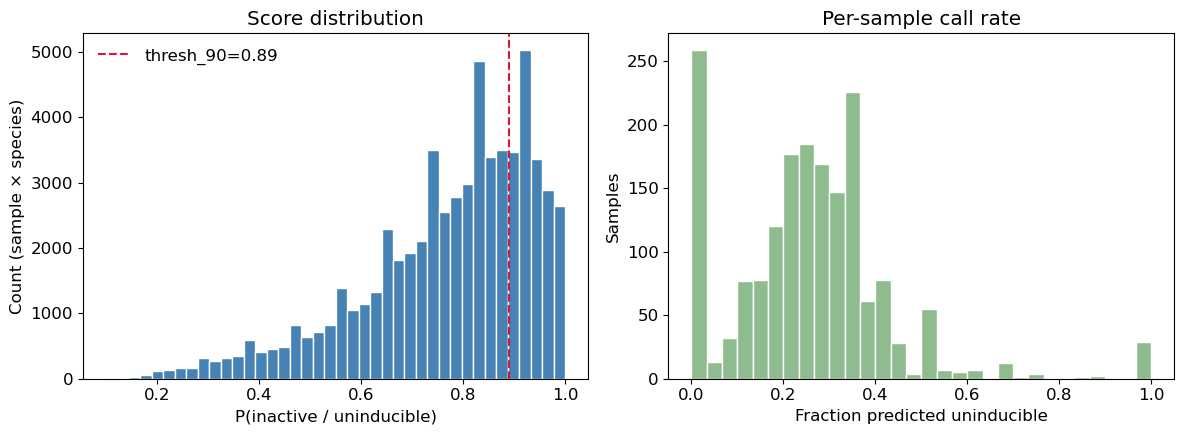

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results/cf_activity_score_distribution.png


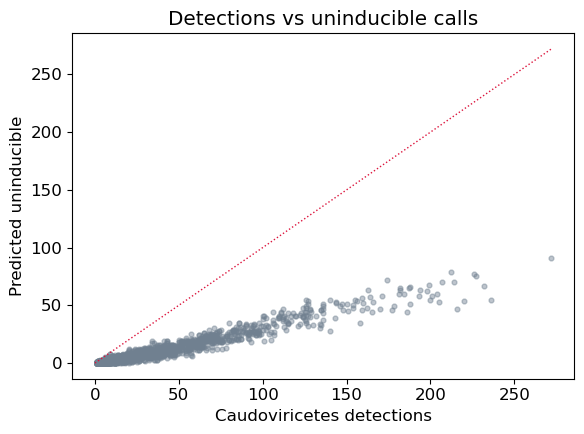

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results/cf_activity_detections_vs_calls.png


In [10]:
### Summary plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(
    scored["predicted_inactive_probability"],
    bins=40,
    color="steelblue",
    edgecolor="white",
)
axes[0].axvline(thr, color="crimson", linestyle="--", label=f"thresh_90={thr:.2f}")
axes[0].set_xlabel("P(inactive / uninducible)")
axes[0].set_ylabel("Count (sample × species)")
axes[0].set_title("Score distribution")
axes[0].legend(frameon=False)

axes[1].hist(
    per_sample["prop_predicted_uninducible"],
    bins=30,
    color="darkseagreen",
    edgecolor="white",
)
axes[1].set_xlabel("Fraction predicted uninducible")
axes[1].set_ylabel("Samples")
axes[1].set_title("Per-sample call rate")

fig.tight_layout()
score_png = OUT_DIR / "cf_activity_score_distribution.png"
fig.savefig(score_png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", score_png)

fig2, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(
    per_sample["n_detections"],
    per_sample["n_predicted_uninducible"],
    s=12,
    alpha=0.45,
    color="slategray",
)
mx = max(per_sample["n_detections"].max(), 1)
ax.plot([0, mx], [0, mx], color="crimson", linestyle=":", linewidth=1)
ax.set_xlabel("Caudoviricetes detections")
ax.set_ylabel("Predicted uninducible")
ax.set_title("Detections vs uninducible calls")
fig2.tight_layout()
scatter_png = OUT_DIR / "cf_activity_detections_vs_calls.png"
fig2.savefig(scatter_png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", scatter_png)


In [11]:
### Sample-type designation (upper vs lower airway)
# Labels written to cf_activity_results/cf_sample_type_airway3.tsv.
#
# Sources (in priority order for most samples):
#   1. figure_6/cf_longitudinal_samplesheet.csv `sample_type` when present
#   2. EBI BioSamples metadata for the sample's BioSample accession
#      (isolation_source, environment (material), host body product, title, …)
#   3. Study-level overrides from publications / manual review (below)
#
# Keyword mapping from BioSample / title text → fine type:
#   BAL:     bal, bronchoalveolar, bronchial lavage
#   sputum:  sputum; title codes with `_SP`
#   swab:    oropharyn, nasopharyn, throat/oral/nasal swab, buccal, nasal lavage,
#            generic "swab"; title codes `_OF` / `_SAL` (PRJEB79033); RA → upper
#   unknown: leftover sparse titles without anatomic info
#
# Collapsed airway categories used in plots:
#   lower_airway = sputum + BAL
#   upper_airway = OP/NP/throat/nasal swabs + RA + OF/SAL
#   other        = unknown (currently PRJEB50802 only)
#
# Bioproject overrides applied after automatic parsing:
#   PRJNA516870, PRJNA316056, PRJEB54014          → sputum (lower)
#   PRJEB38221, PRJNA1055940                      → upper
#   PRJEB51171  SP→sputum, RA→upper
#   PRJEB79033  SP→sputum, OF/SAL→upper
#   PRJEB50802                                    → unknown (other)
#   PRJNA530252 "stool" BioSample tags kept as sputum (publication/sheet)
#   Local LiPuma-style IDs (L#####, no SRA accession) → sputum

AIRWAY_LABELS = OUT_DIR / "cf_sample_type_airway3.tsv"
airway_df = pl.read_csv(AIRWAY_LABELS, separator="\t")

print(f"Loaded {AIRWAY_LABELS.name}: {airway_df.height:,} CoverM samples")
print("\nAirway category counts:")
print(
    airway_df.group_by("airway_category")
    .agg(pl.len().alias("n_samples"))
    .with_columns(
        pl.col("airway_category")
        .replace({"upper_airway": 0, "lower_airway": 1, "other": 2})
        .alias("_ord")
    )
    .sort("_ord")
    .drop("_ord")
)
print("\nFine type × airway:")
print(
    airway_df.group_by(["airway_category", "fine_type"])
    .agg(pl.len().alias("n_samples"))
    .with_columns(
        [
            pl.col("airway_category")
            .replace({"upper_airway": 0, "lower_airway": 1, "other": 2})
            .alias("_a"),
            pl.col("fine_type").alias("_f"),
        ]
    )
    .sort(["_a", "n_samples"], descending=[False, True])
    .drop(["_a", "_f"])
)
print("\nLabel source:")
print(airway_df.group_by("label_source").agg(pl.len().alias("n")).sort("n", descending=True))
airway_df.head()


Loaded cf_sample_type_airway3.tsv: 1,809 CoverM samples

Airway category counts:
shape: (3, 2)
┌─────────────────┬───────────┐
│ airway_category ┆ n_samples │
│ ---             ┆ ---       │
│ str             ┆ u32       │
╞═════════════════╪═══════════╡
│ upper_airway    ┆ 899       │
│ lower_airway    ┆ 874       │
│ other           ┆ 36        │
└─────────────────┴───────────┘

Fine type × airway:
shape: (5, 3)
┌─────────────────┬───────────┬───────────┐
│ airway_category ┆ fine_type ┆ n_samples │
│ ---             ┆ ---       ┆ ---       │
│ str             ┆ str       ┆ u32       │
╞═════════════════╪═══════════╪═══════════╡
│ upper_airway    ┆ swab      ┆ 847       │
│ upper_airway    ┆ RA        ┆ 52        │
│ lower_airway    ┆ sputum    ┆ 866       │
│ lower_airway    ┆ BAL       ┆ 8         │
│ other           ┆ unknown   ┆ 36        │
└─────────────────┴───────────┴───────────┘

Label source:
shape: (3, 2)
┌──────────────┬──────┐
│ label_source ┆ n    │
│ ---          ┆ --- 

sample_id,biosample,run,bioproject,sheet_type,sheet_coarse,sra_type,match_rule,evidence,fine_type,label_source,airway_category,title,isolation_source,env_material
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""SAMN11310355_SRR8834181_cf""","""SAMN11310355""","""SRR8834181""","""PRJNA530252""","""sputum""","""sputum""","""stool""","""bioproject_override_stool_is_s…","""stool | n315s0 | collection co…","""sputum""","""sheet""","""lower_airway""","""N315S0""",null,"""stool"""
"""SAMN10805679_SRR8482137_cf""","""SAMN10805679""","""SRR8482137""","""PRJNA516870""","""sputum""","""sputum""","""lung_ambiguous""","""bioproject_PRJNA516870_sputum""","""mims environmental/metagenome …","""sputum""","""bioproject""","""lower_airway""","""MIMS Environmental/Metagenome …",null,null
"""SAMN33100595_SRR23346065_cf""","""SAMN33100595""","""SRR23346065""","""PRJNA931830""","""oropharyngeal swabs""","""swab""","""other""","""no_rule""","""oropharyngeal swabs | metageno…","""swab""","""sheet""","""upper_airway""","""Metagenome or environmental sa…","""oropharyngeal swabs""",null
"""SAMEA6820368_ERR4129703_cf""","""SAMEA6820368""","""ERR4129703""","""PRJEB38221""",null,null,"""lung_ambiguous""","""bioproject_PRJEB38221_upper""","""airway metagenome | cf""","""swab""","""bioproject""","""upper_airway""","""Airway metagenome""",null,null
"""SAMEA6820376_ERR4129711_cf""","""SAMEA6820376""","""ERR4129711""","""PRJEB38221""",null,null,"""lung_ambiguous""","""bioproject_PRJEB38221_upper""","""airway metagenome | cf""","""swab""","""bioproject""","""upper_airway""","""Airway metagenome""",null,null


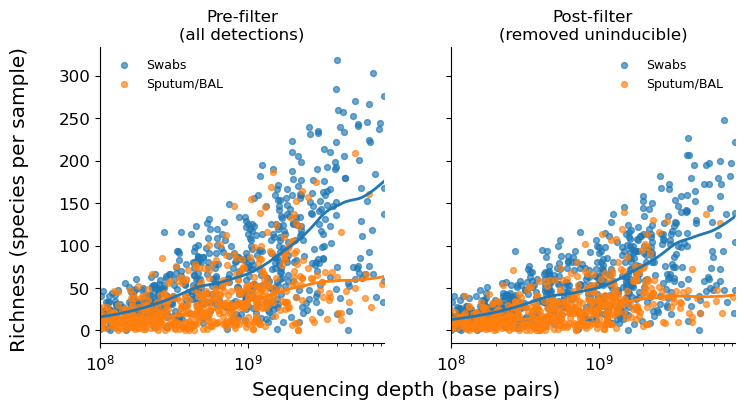

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results/cf_activity_counts_by_read_depth.png
all_detections=71,950  removed_uninducible=17,391
shape: (4, 5)
┌─────────────────────┬──────────────┬───────────┬──────────────┬────────────────┐
│ filter_stage        ┆ airway_label ┆ n_samples ┆ mean_species ┆ median_species │
│ ---                 ┆ ---          ┆ ---       ┆ ---          ┆ ---            │
│ str                 ┆ str          ┆ u32       ┆ f64          ┆ f64            │
╞═════════════════════╪══════════════╪═══════════╪══════════════╪════════════════╡
│ Post-filter         ┆ Sputum/BAL   ┆ 158       ┆ 43.810127    ┆ 36.0           │
│ (removed uninducib… ┆              ┆           ┆              ┆                │
│ Post-filter         ┆ Swabs        ┆ 273       ┆ 84.216117    ┆ 76.0           │
│ (removed uninducib… ┆              ┆           ┆              ┆                │
│ Pre-filter          ┆ Sputum/BAL 

In [12]:
### Species counts vs read depth (pre- vs post-filter)
# Same style as figure_5.ipynb: FacetGrid + LOWESS regplot.
# Pre-filter = all UHVDB species-rep detections (any ICTV class).
# Post-filter = same set after removing predicted-uninducible Caudoviricetes.
# Points/curves colored by upper vs lower airway (cf_sample_type_airway3.tsv).

read_depth = (
    pl.read_csv(FIG_5 / "cf_metag_read_depth.txt.gz", separator="\t", has_header=False)
    .rename({"column_1": "sample_id", "column_2": "read_depth"})
)

airway_labels = (
    pl.read_csv(OUT_DIR / "cf_sample_type_airway3.tsv", separator="\t")
    .select(["sample_id", "airway_category"])
    .unique("sample_id")
)

all_detections = (
    coverm_df.filter(pl.col("breadth_ratio") > 0)
    .join(_id_ictv, left_on="contig_id", right_on="uhvdb_id", how="left")
    .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .sort(
        ["sample_id", "species_cluster_id", "breadth_ratio"],
        descending=[False, False, True],
    )
    .unique(["sample_id", "species_cluster_id"], keep="first")
    .select(["sample_id", "species_cluster_id", "ictv_class"])
    .join(read_depth, on="sample_id", how="left")
)

uninducible = (
    pl.from_pandas(scored[["sample_id", "species_cluster_id", "predicted_uninducible"]].copy())
    .with_columns(pl.col("predicted_uninducible").cast(pl.Int64))
    .filter(pl.col("predicted_uninducible") == 1)
    .select(["sample_id", "species_cluster_id"])
)

pre_filter = (
    all_detections.group_by(["sample_id", "read_depth"])
    .len()
    .with_columns(pl.lit("Pre-filter\n(all detections)").alias("filter_stage"))
)

post_filter = (
    all_detections.join(uninducible, on=["sample_id", "species_cluster_id"], how="anti")
    .group_by(["sample_id", "read_depth"])
    .len()
    .with_columns(pl.lit("Post-filter\n(removed uninducible)").alias("filter_stage"))
)

airway_order = ["upper_airway", "lower_airway"]
airway_display = {"upper_airway": "Swabs", "lower_airway": "Sputum/BAL"}
airway_palette = {"upper_airway": "#1f77b4", "lower_airway": "#ff7f0e"}

depth_plot_df = (
    pl.concat([pre_filter, post_filter])
    .filter(pl.col("read_depth").is_not_null())
    .join(airway_labels, on="sample_id", how="left")
    .filter(pl.col("airway_category").is_in(airway_order))
    .with_columns(
        pl.col("airway_category").replace(airway_display).alias("airway_label")
    )
)
filter_order = [
    "Pre-filter\n(all detections)",
    "Post-filter\n(removed uninducible)",
]
x_max = depth_plot_df.select(pl.col("read_depth").quantile(0.99)).item()
pdf = depth_plot_df.to_pandas()

g = sns.FacetGrid(
    pdf,
    col="filter_stage",
    col_order=filter_order,
    col_wrap=2,
    height=4.0,
    aspect=0.9,
    sharex=True,
    sharey=True,
    margin_titles=True,
)

for ax, stage in zip(g.axes.flatten(), filter_order):
    for cat in airway_order:
        sub = pdf[(pdf["filter_stage"] == stage) & (pdf["airway_category"] == cat)]
        if sub.empty:
            continue
        sns.regplot(
            data=sub,
            x="read_depth",
            y="len",
            lowess=True,
            scatter_kws={"s": 18, "alpha": 0.65},
            line_kws={"linewidth": 2.0},
            color=airway_palette[cat],
            label=airway_display[cat],
            ax=ax,
        )
    ax.set_xlim(1e8, x_max)
    ax.set_xscale("log")
    ax.set_xlabel("")
    ax.legend(frameon=False, fontsize=9)

g.set_ylabels("")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.88, bottom=0.14)
g.fig.supxlabel("Sequencing depth (base pairs)", y=0, x=0.5)
g.fig.supylabel("Richness (species per sample)", x=-0.05)

depth_png = OUT_DIR / "cf_activity_counts_by_read_depth.png"
g.fig.savefig(depth_png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", depth_png)
print(
    f"all_detections={all_detections.height:,}  "
    f"removed_uninducible={uninducible.height:,}"
)
print(
    depth_plot_df.filter(pl.col("read_depth") >= 1e9)
    .group_by(["filter_stage", "airway_label"])
    .agg(
        [
            pl.len().alias("n_samples"),
            pl.col("len").mean().alias("mean_species"),
            pl.col("len").median().alias("median_species"),
        ]
    )
    .sort(["filter_stage", "airway_label"])
)
print(
    "\nSamples in plot by airway:",
    depth_plot_df.group_by("airway_label").agg(
        pl.col("sample_id").n_unique().alias("n_samples")
    ),
)


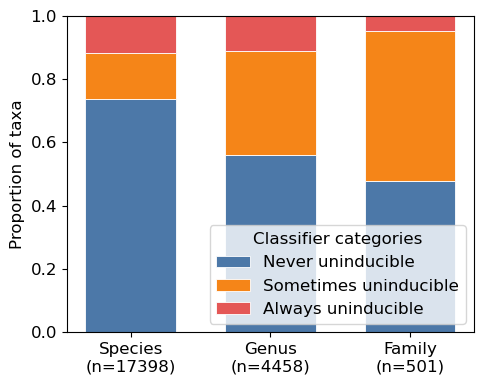

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results/cf_activity_uninducible_consistency.png


taxonomic_level,category,n_taxa,proportion
str,str,u32,f64
"""Species""","""Never uninducible""",12812,0.736406
"""Species""","""Sometimes uninducible""",2535,0.145706
"""Species""","""Always uninducible""",2051,0.117887
"""Genus""","""Never uninducible""",2497,0.560117
"""Genus""","""Sometimes uninducible""",1472,0.330193
"""Genus""","""Always uninducible""",489,0.10969
"""Family""","""Never uninducible""",239,0.477046
"""Family""","""Sometimes uninducible""",238,0.47505
"""Family""","""Always uninducible""",24,0.047904


In [13]:
### Uninducible consistency across samples (species / genus / family)
# For each taxon, among samples where it is detected:
#   - Never uninducible: never predicted uninducible
#   - Sometimes uninducible: predicted uninducible in some but not all detections
#   - Always uninducible: predicted uninducible in every detection
# Non-Caudoviricetes detections (unscored) count as not uninducible.
# Higher ranks: a genus/family is uninducible in a sample if ANY detected member
# species is predicted uninducible in that sample.

sp_tax = (
    uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .select(["species_cluster_id", "genus_cluster_id", "family_cluster_id"])
    .unique("species_cluster_id")
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
)

if "all_detections" not in globals():
    all_detections = (
        coverm_df.filter(pl.col("breadth_ratio") > 0)
        .join(_id_ictv, left_on="contig_id", right_on="uhvdb_id", how="left")
        .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
        .sort(
            ["sample_id", "species_cluster_id", "breadth_ratio"],
            descending=[False, False, True],
        )
        .unique(["sample_id", "species_cluster_id"], keep="first")
        .select(["sample_id", "species_cluster_id", "ictv_class"])
    )

pred_flags = (
    pl.from_pandas(scored[["sample_id", "species_cluster_id", "predicted_uninducible"]].copy())
    .with_columns(pl.col("predicted_uninducible").cast(pl.Int64))
    .select(["sample_id", "species_cluster_id", "predicted_uninducible"])
)

det_with_pred = (
    all_detections.join(sp_tax, on="species_cluster_id", how="left")
    .join(pred_flags, on=["sample_id", "species_cluster_id"], how="left")
    .with_columns(pl.col("predicted_uninducible").fill_null(0))
)


def consistency_category(det: pl.DataFrame, taxon_col: str, level_name: str) -> pl.DataFrame:
    # Per sample × taxon: uninducible if any member species is uninducible
    sample_taxon = (
        det.filter(pl.col(taxon_col).is_not_null())
        .group_by(["sample_id", taxon_col])
        .agg(pl.col("predicted_uninducible").max().alias("is_uninducible"))
    )
    return (
        sample_taxon.group_by(taxon_col)
        .agg(
            [
                pl.len().alias("n_samples"),
                pl.col("is_uninducible").sum().alias("n_uninducible"),
            ]
        )
        .with_columns(
            pl.when(pl.col("n_uninducible") == 0)
            .then(pl.lit("Never uninducible"))
            .when(pl.col("n_uninducible") == pl.col("n_samples"))
            .then(pl.lit("Always uninducible"))
            .otherwise(pl.lit("Sometimes uninducible"))
            .alias("category")
        )
        .with_columns(pl.lit(level_name).alias("taxonomic_level"))
        .rename({taxon_col: "taxon_id"})
    )


consistency_df = pl.concat(
    [
        consistency_category(det_with_pred, "species_cluster_id", "Species"),
        consistency_category(det_with_pred, "genus_cluster_id", "Genus"),
        consistency_category(det_with_pred, "family_cluster_id", "Family"),
    ]
)

category_order = ["Never uninducible", "Sometimes uninducible", "Always uninducible"]
level_order = ["Species", "Genus", "Family"]
palette = {
    "Never uninducible": "#4C78A8",
    "Sometimes uninducible": "#F58518",
    "Always uninducible": "#E45756",
}

prop_df = (
    consistency_df.group_by(["taxonomic_level", "category"])
    .agg(pl.len().alias("n_taxa"))
    .with_columns(
        (pl.col("n_taxa") / pl.col("n_taxa").sum().over("taxonomic_level")).alias("proportion")
    )
    .to_pandas()
)

prop_wide = (
    prop_df.pivot(index="taxonomic_level", columns="category", values="proportion")
    .reindex(index=level_order, columns=category_order)
    .fillna(0.0)
)
count_wide = (
    prop_df.pivot(index="taxonomic_level", columns="category", values="n_taxa")
    .reindex(index=level_order, columns=category_order)
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(5, 4))
bottom = np.zeros(len(level_order))
x = np.arange(len(level_order))
for cat in category_order:
    vals = prop_wide[cat].to_numpy()
    ax.bar(
        x,
        vals,
        bottom=bottom,
        width=0.65,
        label=cat,
        color=palette[cat],
        edgecolor="white",
        linewidth=0.6,
    )
    bottom = bottom + vals

n_per_level = count_wide.sum(axis=1).to_dict()
ax.set_xticks(x)
ax.set_xticklabels([f"{lvl}\n(n={n_per_level.get(lvl, 0)})" for lvl in level_order])
ax.set_ylabel("Proportion of taxa")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.legend(title="Classifier categories", frameon=True, loc="lower right")
fig.tight_layout()

consist_png = OUT_DIR / "cf_activity_uninducible_consistency.png"
fig.savefig(consist_png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", consist_png)

consistency_summary = (
    consistency_df.group_by(["taxonomic_level", "category"])
    .agg(pl.len().alias("n_taxa"))
    .with_columns(
        [
            (pl.col("n_taxa") / pl.col("n_taxa").sum().over("taxonomic_level")).alias(
                "proportion"
            ),
            pl.col("taxonomic_level")
            .replace({"Species": 0, "Genus": 1, "Family": 2})
            .alias("_lvl"),
            pl.col("category")
            .replace(
                {
                    "Never uninducible": 0,
                    "Sometimes uninducible": 1,
                    "Always uninducible": 2,
                }
            )
            .alias("_cat"),
        ]
    )
    .sort(["_lvl", "_cat"])
    .drop(["_lvl", "_cat"])
)
consistency_summary


Deep samples (read_depth >= 1e+08) used for prevalence:
shape: (2, 2)
┌──────────────┬───────────┐
│ airway_label ┆ n_samples │
│ ---          ┆ ---       │
│ str          ┆ u32       │
╞══════════════╪═══════════╡
│ Sputum/BAL   ┆ 539       │
│ Swabs        ┆ 612       │
└──────────────┴───────────┘

Median/mean prevalence (deep samples, by airway):
shape: (6, 5)
┌──────────────┬─────────────────┬────────┬───────────────────┬─────────────────┐
│ airway_label ┆ taxonomic_level ┆ n_taxa ┆ median_prevalence ┆ mean_prevalence │
│ ---          ┆ ---             ┆ ---    ┆ ---               ┆ ---             │
│ str          ┆ str             ┆ u32    ┆ f64               ┆ f64             │
╞══════════════╪═════════════════╪════════╪═══════════════════╪═════════════════╡
│ Sputum/BAL   ┆ Species         ┆ 7131   ┆ 0.185529          ┆ 0.498854        │
│ Sputum/BAL   ┆ Genus           ┆ 2505   ┆ 0.371058          ┆ 1.293147        │
│ Sputum/BAL   ┆ Family          ┆ 371    ┆ 1.48423        

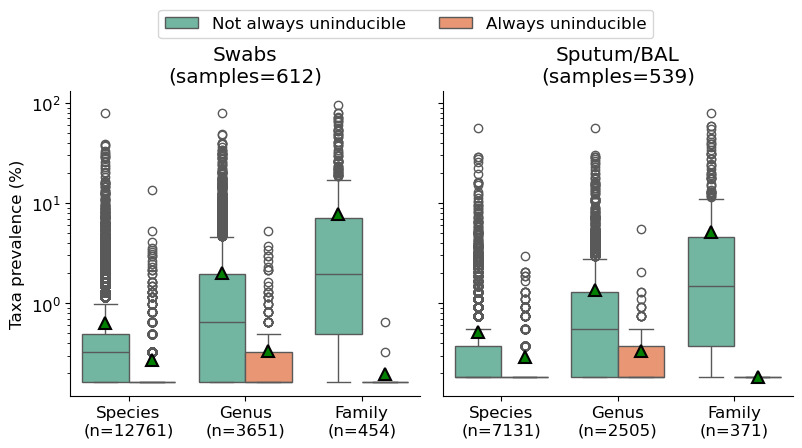

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results/cf_activity_prevalence_by_rank.png


airway_label,consistency,taxonomic_level,n_taxa,mean_prevalence,median_prevalence,max_prevalence
str,str,str,u32,f64,f64,f64
"""Sputum/BAL""","""Not always uninducible""","""Species""",6484,0.519961,0.185529,55.844156
"""Sputum/BAL""","""Not always uninducible""","""Genus""",2341,1.360201,0.556586,56.029685
"""Sputum/BAL""","""Not always uninducible""","""Family""",366,5.192778,1.48423,79.406308
"""Sputum/BAL""","""Always uninducible""","""Species""",647,0.287326,0.185529,2.96846
"""Sputum/BAL""","""Always uninducible""","""Genus""",164,0.335988,0.185529,5.565863
"""Sputum/BAL""","""Always uninducible""","""Family""",5,0.185529,0.185529,0.185529
"""Swabs""","""Not always uninducible""","""Species""",11164,0.638315,0.326797,78.594771
"""Swabs""","""Not always uninducible""","""Genus""",3267,2.025204,0.653595,79.084967
"""Swabs""","""Not always uninducible""","""Family""",433,7.786533,1.960784,94.934641


In [14]:
### Prevalence at species / genus / family by uninducible consistency
# Prevalence = (# deep samples with taxon detected) / (# deep samples in cohort) * 100.
# Cohort = CoverM samples with read_depth >= 1e9, split by upper vs lower airway.
# Consistency collapsed to: Always uninducible vs Not always uninducible
#   (Never + Sometimes → Not always). Categories from consistency_df (prior cell).

DEPTH_MIN = 1e8

sp_tax = (
    uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .select(["species_cluster_id", "genus_cluster_id", "family_cluster_id"])
    .unique("species_cluster_id")
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
)

if "read_depth" not in globals():
    read_depth = (
        pl.read_csv(FIG_5 / "cf_metag_read_depth.txt.gz", separator="\t", has_header=False)
        .rename({"column_1": "sample_id", "column_2": "read_depth"})
    )

if "airway_labels" not in globals():
    airway_labels = (
        pl.read_csv(OUT_DIR / "cf_sample_type_airway3.tsv", separator="\t")
        .select(["sample_id", "airway_category"])
        .unique("sample_id")
    )

if "all_detections" not in globals():
    all_detections = (
        coverm_df.filter(pl.col("breadth_ratio") > 0)
        .join(_id_ictv, left_on="contig_id", right_on="uhvdb_id", how="left")
        .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
        .sort(
            ["sample_id", "species_cluster_id", "breadth_ratio"],
            descending=[False, False, True],
        )
        .unique(["sample_id", "species_cluster_id"], keep="first")
        .select(["sample_id", "species_cluster_id", "ictv_class"])
    )

if "consistency_df" not in globals():
    raise RuntimeError("Run the uninducible-consistency cell first to build consistency_df")

deep_samples = (
    coverm_df.select("sample_id")
    .unique()
    .join(read_depth, on="sample_id", how="left")
    .join(airway_labels, on="sample_id", how="left")
    .filter(pl.col("read_depth") >= DEPTH_MIN)
    .filter(pl.col("airway_category").is_in(["upper_airway", "lower_airway"]))
    .with_columns(
        pl.col("airway_category")
        .replace({"upper_airway": "Swabs", "lower_airway": "Sputum/BAL"})
        .alias("airway_label")
    )
)

airway_n = {
    str(r["airway_label"]): int(r["n"])
    for r in deep_samples.group_by("airway_label").agg(pl.len().alias("n")).iter_rows(named=True)
}
print(
    f"Deep samples (read_depth >= {DEPTH_MIN:.0e}) used for prevalence:"
)
print(deep_samples.group_by("airway_label").agg(pl.len().alias("n_samples")).sort("airway_label"))

detections_deep = (
    all_detections.join(
        deep_samples.select(["sample_id", "airway_label"]),
        on="sample_id",
        how="inner",
    ).join(sp_tax, on="species_cluster_id", how="left")
)


def prevalence_table_by_airway(
    det: pl.DataFrame, taxon_col: str, level_name: str
) -> pl.DataFrame:
    rows = []
    for airway, n_samp in airway_n.items():
        rows.append(
            det.filter(pl.col("airway_label") == airway)
            .filter(pl.col(taxon_col).is_not_null())
            .group_by(taxon_col)
            .agg(pl.col("sample_id").n_unique().alias("n_samples_detected"))
            .with_columns(
                [
                    (pl.col("n_samples_detected") * 100 / n_samp).alias("prevalence"),
                    pl.lit(level_name).alias("taxonomic_level"),
                    pl.lit(airway).alias("airway_label"),
                ]
            )
            .rename({taxon_col: "taxon_id"})
        )
    return pl.concat(rows) if rows else pl.DataFrame()


prevalence_all = pl.concat(
    [
        prevalence_table_by_airway(detections_deep, "species_cluster_id", "Species"),
        prevalence_table_by_airway(detections_deep, "genus_cluster_id", "Genus"),
        prevalence_table_by_airway(detections_deep, "family_cluster_id", "Family"),
    ]
)

consistency_2 = consistency_df.with_columns(
    pl.when(pl.col("category") == "Always uninducible")
    .then(pl.lit("Always uninducible"))
    .otherwise(pl.lit("Not always uninducible"))
    .alias("consistency")
)

prevalence_df = prevalence_all.join(
    consistency_2.select(["taxon_id", "taxonomic_level", "consistency"]),
    on=["taxon_id", "taxonomic_level"],
    how="inner",
)

overall_median_prev = (
    prevalence_df.group_by(["airway_label", "taxonomic_level"])
    .agg(
        [
            pl.len().alias("n_taxa"),
            pl.col("prevalence").median().alias("median_prevalence"),
            pl.col("prevalence").mean().alias("mean_prevalence"),
        ]
    )
    .with_columns(
        pl.col("taxonomic_level")
        .replace({"Species": 0, "Genus": 1, "Family": 2})
        .alias("_ord")
    )
    .sort(["airway_label", "_ord"])
    .drop("_ord")
)
print("\nMedian/mean prevalence (deep samples, by airway):")
print(overall_median_prev)

n_high_prev = (
    prevalence_df.filter(pl.col("prevalence") >= 10)
    .group_by(["airway_label", "taxonomic_level"])
    .agg(pl.len().alias("n_taxa_ge_10pct"))
    .with_columns(
        pl.col("taxonomic_level")
        .replace({"Species": 0, "Genus": 1, "Family": 2})
        .alias("_ord")
    )
    .sort(["airway_label", "_ord"])
    .drop("_ord")
)
print("\nTaxa with prevalence >= 10%:")
print(n_high_prev)

prevalence_pdf = prevalence_df.to_pandas()

level_order = ["Species", "Genus", "Family"]
airway_order = ["Swabs", "Sputum/BAL"]
consistency_order = ["Not always uninducible", "Always uninducible"]
meanprops = {
    "marker": "^",
    "markerfacecolor": "green",
    "markeredgecolor": "black",
    "markersize": 9,
    "markeredgewidth": 1.5,
}

g = sns.FacetGrid(
    prevalence_pdf,
    col="airway_label",
    col_order=airway_order,
    height=4.5,
    aspect=0.9,
    sharex=False,
    sharey=True,
)


def _boxplot_prevalence(data, color, **kwargs):
    return sns.boxplot(
        data=data,
        x="taxonomic_level",
        y="prevalence",
        order=level_order,
        hue="consistency",
        hue_order=consistency_order,
        palette="Set2",
        showfliers=True,
        showmeans=True,
        meanprops=meanprops,
        ax=plt.gca(),
    )


g.map_dataframe(_boxplot_prevalence)

counts = (
    prevalence_df.group_by(["airway_label", "consistency", "taxonomic_level"])
    .agg(pl.len().alias("n_taxa"))
    .to_pandas()
)
count_map = {
    (
        str(row["airway_label"]),
        str(row["consistency"]),
        str(row["taxonomic_level"]),
    ): int(row["n_taxa"])
    for _, row in counts.iterrows()
}
legend_handles, legend_labels = None, None
for ax, airway in zip(g.axes.flatten(), airway_order):
    ax.set_yscale("log")
    ax.set_xlabel("")
    ax.set_title(f"{airway}\n(samples={airway_n.get(airway, 0)})")
    # xtick labels with n per consistency are crowded; put total n per level
    n_per_level = {
        lvl: sum(
            count_map.get((airway, cons, lvl), 0) for cons in consistency_order
        )
        for lvl in level_order
    }
    ax.set_xticks(range(len(level_order)))
    ax.set_xticklabels(
        [f"{lvl}\n(n={n_per_level[lvl]})" for lvl in level_order]
    )
    handles, labels = ax.get_legend_handles_labels()
    if handles and legend_handles is None:
        legend_handles, legend_labels = handles[:2], labels[:2]
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

g.set_ylabels("Taxa prevalence (%)")
if legend_handles:
    g.fig.legend(
        legend_handles,
        legend_labels,
        loc="upper center",
        ncol=2,
        frameon=True,
        fontsize=12,
        bbox_to_anchor=(0.5, 1.02),
    )
g.fig.subplots_adjust(top=0.82)

prev_png = OUT_DIR / "cf_activity_prevalence_by_rank.png"
g.fig.savefig(prev_png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", prev_png)

prevalence_summary = (
    prevalence_df.group_by(["airway_label", "consistency", "taxonomic_level"])
    .agg(
        [
            pl.len().alias("n_taxa"),
            pl.col("prevalence").mean().alias("mean_prevalence"),
            pl.col("prevalence").median().alias("median_prevalence"),
            pl.col("prevalence").max().alias("max_prevalence"),
        ]
    )
    .with_columns(
        [
            pl.col("taxonomic_level")
            .replace({"Species": 0, "Genus": 1, "Family": 2})
            .alias("_ord"),
            pl.col("airway_label")
            .replace({"swabs": 0, "sputum/BAL": 1})
            .alias("_air"),
            pl.col("consistency")
            .replace(
                {
                    "Not always uninducible": 0,
                    "Always uninducible": 1,
                }
            )
            .alias("_cons"),
        ]
    )
    .sort(["_air", "_cons", "_ord"])
    .drop(["_ord", "_air", "_cons"])
)
prevalence_summary.head(10)


In [16]:
# species mean not always uninducible v always uninducible across sample types
species_means = (
    prevalence_summary.filter(pl.col("taxonomic_level") == "Species")
    .select(["airway_label", "consistency", "n_taxa", "mean_prevalence"])
    .sort(["airway_label", "consistency"])
)
print("Species mean prevalence (%) by uninducible consistency × sample type:")
print(species_means)
for airway in ["Swabs", "Sputum/BAL"]:
    sub = species_means.filter(pl.col("airway_label") == airway)
    not_always = sub.filter(pl.col("consistency") == "Not always uninducible")
    always = sub.filter(pl.col("consistency") == "Always uninducible")
    if not_always.height and always.height:
        m_na = float(not_always["mean_prevalence"][0])
        m_a = float(always["mean_prevalence"][0])
        print(
            f"  {airway}: not always={m_na:.4f}%  "
            f"always={m_a:.4f}%  "
            f"(ratio not-always/always={m_na / m_a:.2f}x)"
        )


Species mean prevalence (%) by uninducible consistency × sample type:
shape: (4, 4)
┌──────────────┬────────────────────────┬────────┬─────────────────┐
│ airway_label ┆ consistency            ┆ n_taxa ┆ mean_prevalence │
│ ---          ┆ ---                    ┆ ---    ┆ ---             │
│ str          ┆ str                    ┆ u32    ┆ f64             │
╞══════════════╪════════════════════════╪════════╪═════════════════╡
│ Sputum/BAL   ┆ Always uninducible     ┆ 647    ┆ 0.287326        │
│ Sputum/BAL   ┆ Not always uninducible ┆ 6484   ┆ 0.519961        │
│ Swabs        ┆ Always uninducible     ┆ 1597   ┆ 0.273286        │
│ Swabs        ┆ Not always uninducible ┆ 11164  ┆ 0.638315        │
└──────────────┴────────────────────────┴────────┴─────────────────┘
  Swabs: not always=0.6383%  always=0.2733%  (ratio not-always/always=2.34x)
  Sputum/BAL: not always=0.5200%  always=0.2873%  (ratio not-always/always=1.81x)

Overall species mean prevalence (%) (n_deep=1151, pooled airways):

Deep samples (read_depth >= 1e+08) used for bacterial prevalence:
shape: (2, 2)
┌──────────────┬───────────┐
│ airway_label ┆ n_samples │
│ ---          ┆ ---       │
│ str          ┆ u32       │
╞══════════════╪═══════════╡
│ Sputum/BAL   ┆ 539       │
│ Swabs        ┆ 612       │
└──────────────┴───────────┘

Bacterial prevalence summary:
shape: (6, 7)
┌──────────────┬──────────────┬────────┬──────────────┬──────────────┬──────────────┬──────────────┐
│ airway_label ┆ taxonomic_le ┆ n_taxa ┆ mean_prevale ┆ median_preva ┆ max_prevalen ┆ n_taxa_ge_10 │
│ ---          ┆ vel          ┆ ---    ┆ nce          ┆ lence        ┆ ce           ┆ pct          │
│ str          ┆ ---          ┆ u32    ┆ ---          ┆ ---          ┆ ---          ┆ ---          │
│              ┆ str          ┆        ┆ f64          ┆ f64          ┆ f64          ┆ u32          │
╞══════════════╪══════════════╪════════╪══════════════╪══════════════╪══════════════╪══════════════╡
│ Swabs        ┆ Species      ┆ 1246 

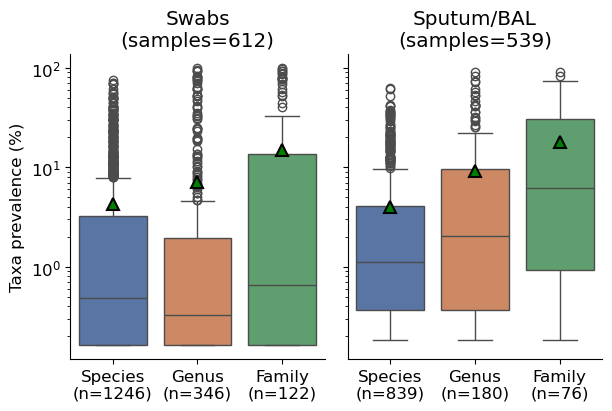

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results/cf_activity_bacterial_prevalence_by_rank.png


airway_label,taxonomic_level,n_taxa,mean_prevalence,median_prevalence,max_prevalence,n_taxa_ge_10pct
str,str,u32,f64,f64,f64,u32
"""Swabs""","""Species""",1246,4.244694,0.490196,75.0,150
"""Swabs""","""Genus""",346,7.146568,0.326797,98.856209,50
"""Swabs""","""Family""",122,15.034019,0.653595,98.856209,35
"""Sputum/BAL""","""Species""",839,3.953819,1.113173,62.337662,88
"""Sputum/BAL""","""Genus""",180,9.213564,2.040816,90.166976,43
"""Sputum/BAL""","""Family""",76,18.032907,6.122449,90.166976,33


In [75]:
### Bacterial prevalence at species / genus / family (Sylph GTDB taxonomy)
# Prevalence = (# deep samples with taxon detected) / (# deep samples in cohort) * 100.
# Detection = relative_abundance > 0 at the leaf rank (s__ / g__ / f__).
# Cohort = CoverM samples with read_depth >= 1e8, split by upper vs lower airway.

DEPTH_MIN = 1e8

SYLPH_TAX = FIG_5 / "cf_metag_sylph_tax_results.tsv.gz"
if "sylph_tax" not in globals():
    sylph_tax = pl.read_csv(SYLPH_TAX, separator="\t")

if "read_depth" not in globals():
    read_depth = (
        pl.read_csv(FIG_5 / "cf_metag_read_depth.txt.gz", separator="\t", has_header=False)
        .rename({"column_1": "sample_id", "column_2": "read_depth"})
    )

if "airway_labels" not in globals():
    airway_labels = (
        pl.read_csv(OUT_DIR / "cf_sample_type_airway3.tsv", separator="\t")
        .select(["sample_id", "airway_category"])
        .unique("sample_id")
    )

deep_samples = (
    coverm_df.select("sample_id")
    .unique()
    .join(read_depth, on="sample_id", how="left")
    .join(airway_labels, on="sample_id", how="left")
    .filter(pl.col("read_depth") >= DEPTH_MIN)
    .filter(pl.col("airway_category").is_in(["upper_airway", "lower_airway"]))
    .with_columns(
        pl.col("airway_category")
        .replace({"upper_airway": "Swabs", "lower_airway": "Sputum/BAL"})
        .alias("airway_label")
    )
)

airway_n = {
    str(r["airway_label"]): int(r["n"])
    for r in deep_samples.group_by("airway_label").agg(pl.len().alias("n")).iter_rows(named=True)
}
print(f"Deep samples (read_depth >= {DEPTH_MIN:.0e}) used for bacterial prevalence:")
print(deep_samples.group_by("airway_label").agg(pl.len().alias("n_samples")).sort("airway_label"))

bac_tax = (
    sylph_tax.join(deep_samples.select(["sample_id", "airway_label"]), on="sample_id", how="inner")
    .filter(pl.col("clade_name").str.starts_with("d__Bacteria"))
    .filter(pl.col("relative_abundance") > 0)
    .with_columns(pl.col("clade_name").str.split("|").list.last().alias("leaf"))
)

bac_detections = pl.concat(
    [
        bac_tax.filter(
            pl.col("leaf").str.starts_with("s__") & ~pl.col("clade_name").str.contains(r"t__")
        ).select(
            [
                "sample_id",
                "airway_label",
                pl.col("leaf").alias("taxon_id"),
                pl.lit("Species").alias("taxonomic_level"),
            ]
        ),
        bac_tax.filter(pl.col("leaf").str.starts_with("g__")).select(
            [
                "sample_id",
                "airway_label",
                pl.col("leaf").alias("taxon_id"),
                pl.lit("Genus").alias("taxonomic_level"),
            ]
        ),
        bac_tax.filter(pl.col("leaf").str.starts_with("f__")).select(
            [
                "sample_id",
                "airway_label",
                pl.col("leaf").alias("taxon_id"),
                pl.lit("Family").alias("taxonomic_level"),
            ]
        ),
    ]
)


def bac_prevalence_by_airway(det: pl.DataFrame) -> pl.DataFrame:
    rows = []
    for airway, n_samp in airway_n.items():
        rows.append(
            det.filter(pl.col("airway_label") == airway)
            .group_by(["taxonomic_level", "taxon_id"])
            .agg(pl.col("sample_id").n_unique().alias("n_samples_detected"))
            .with_columns(
                [
                    (pl.col("n_samples_detected") * 100 / n_samp).alias("prevalence"),
                    pl.lit(airway).alias("airway_label"),
                ]
            )
        )
    return pl.concat(rows) if rows else pl.DataFrame()


bac_prevalence = bac_prevalence_by_airway(bac_detections)

bac_prev_summary = (
    bac_prevalence.group_by(["airway_label", "taxonomic_level"])
    .agg(
        [
            pl.len().alias("n_taxa"),
            pl.col("prevalence").mean().alias("mean_prevalence"),
            pl.col("prevalence").median().alias("median_prevalence"),
            pl.col("prevalence").max().alias("max_prevalence"),
            (pl.col("prevalence") >= 10).sum().alias("n_taxa_ge_10pct"),
        ]
    )
    .with_columns(
        [
            pl.col("taxonomic_level")
            .replace({"Species": 0, "Genus": 1, "Family": 2})
            .alias("_ord"),
            pl.col("airway_label")
            .replace({"Swabs": 0, "Sputum/BAL": 1})
            .alias("_air"),
        ]
    )
    .sort(["_air", "_ord"])
    .drop(["_ord", "_air"])
)
print("\nBacterial prevalence summary:")
print(bac_prev_summary)

bac_prev_pdf = bac_prevalence.to_pandas()
level_order = ["Species", "Genus", "Family"]
airway_order = ["Swabs", "Sputum/BAL"]
meanprops = {
    "marker": "^",
    "markerfacecolor": "green",
    "markeredgecolor": "black",
    "markersize": 9,
    "markeredgewidth": 1.5,
}

g = sns.FacetGrid(
    bac_prev_pdf,
    col="airway_label",
    col_order=airway_order,
    height=4.5,
    aspect=0.7,
    sharex=False,
    sharey=True,
)


def _boxplot_bac_prevalence(data, color, **kwargs):
    return sns.boxplot(
        data=data,
        x="taxonomic_level",
        y="prevalence",
        order=level_order,
        hue="taxonomic_level",
        hue_order=level_order,
        palette="deep",
        dodge=False,
        showfliers=True,
        showmeans=True,
        meanprops=meanprops,
        legend=False,
        ax=plt.gca(),
    )


g.map_dataframe(_boxplot_bac_prevalence)

counts = (
    bac_prevalence.group_by(["airway_label", "taxonomic_level"])
    .agg(pl.len().alias("n_taxa"))
    .to_pandas()
)
count_map = {
    (str(row["airway_label"]), str(row["taxonomic_level"])): int(row["n_taxa"])
    for _, row in counts.iterrows()
}
for ax, airway in zip(g.axes.flatten(), airway_order):
    ax.set_yscale("log")
    ax.set_xlabel("")
    ax.set_title(f"{airway}\n(samples={airway_n.get(airway, 0)})")
    ax.set_xticks(range(len(level_order)))
    ax.set_xticklabels(
        [f"{lvl}\n(n={count_map.get((airway, lvl), 0)})" for lvl in level_order]
    )

g.set_ylabels("Taxa prevalence (%)")
g.fig.subplots_adjust(top=0.82)

bac_prev_png = OUT_DIR / "cf_activity_bacterial_prevalence_by_rank.png"
g.fig.savefig(bac_prev_png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", bac_prev_png)
bac_prev_summary


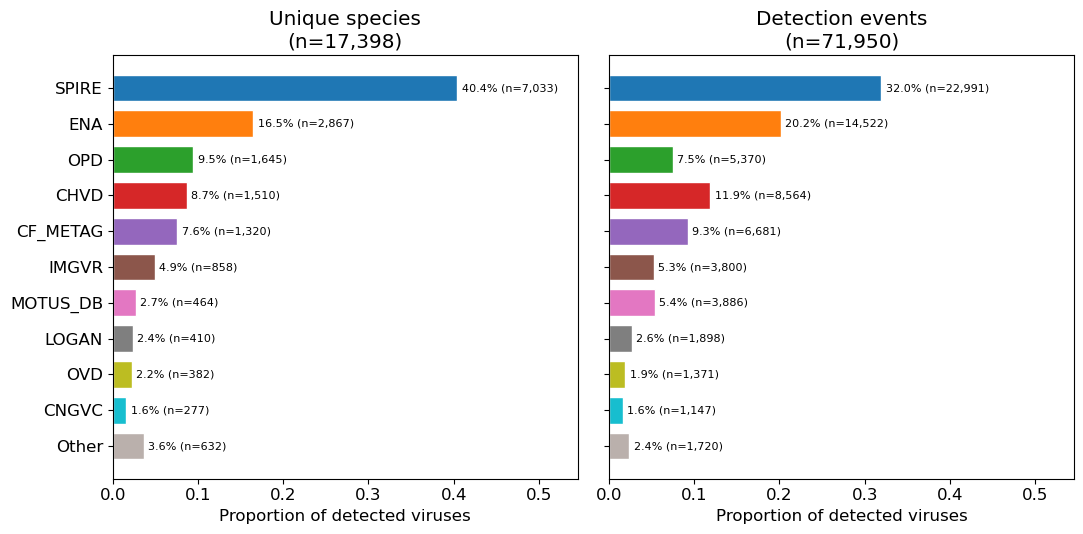

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results/cf_activity_source_db_composition.png
Order: ['SPIRE', 'ENA', 'OPD', 'CHVD', 'CF_METAG', 'IMGVR', 'MOTUS_DB', 'LOGAN', 'OVD', 'CNGVC', 'Other']
shape: (11, 4)
┌──────────────┬──────┬────────────┬────────────────┐
│ source_group ┆ n    ┆ proportion ┆ metric         │
│ ---          ┆ ---  ┆ ---        ┆ ---            │
│ str          ┆ u32  ┆ f64        ┆ str            │
╞══════════════╪══════╪════════════╪════════════════╡
│ SPIRE        ┆ 7033 ┆ 0.404242   ┆ Unique species │
│ ENA          ┆ 2867 ┆ 0.164789   ┆ Unique species │
│ OPD          ┆ 1645 ┆ 0.094551   ┆ Unique species │
│ CHVD         ┆ 1510 ┆ 0.086792   ┆ Unique species │
│ CF_METAG     ┆ 1320 ┆ 0.075871   ┆ Unique species │
│ …            ┆ …    ┆ …          ┆ …              │
│ Other        ┆ 632  ┆ 0.036326   ┆ Unique species │
│ MOTUS_DB     ┆ 464  ┆ 0.02667    ┆ Unique species │
│ LOGAN        ┆ 410  

In [68]:
### Source DB composition of detected species (top 10 + Other)
# Among CoverM species-rep detections, show the top 10 source_db values by
# unique-species count, with all remaining databases collapsed into Other.

sp_source = (
    uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .select(["species_cluster_id", "source_db"])
    .unique("species_cluster_id")
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
)

if "all_detections" not in globals():
    all_detections = (
        coverm_df.filter(pl.col("breadth_ratio") > 0)
        .join(_id_ictv, left_on="contig_id", right_on="uhvdb_id", how="left")
        .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
        .sort(
            ["sample_id", "species_cluster_id", "breadth_ratio"],
            descending=[False, False, True],
        )
        .unique(["sample_id", "species_cluster_id"], keep="first")
        .select(["sample_id", "species_cluster_id", "ictv_class"])
    )

det_source = all_detections.join(sp_source, on="species_cluster_id", how="left").with_columns(
    pl.col("source_db").fill_null("Unknown")
)

n_unique = int(det_source["species_cluster_id"].n_unique())
n_events = int(det_source.height)

# Top 10 by unique detected species count
top10 = (
    det_source.unique("species_cluster_id")
    .group_by("source_db")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
    .head(10)["source_db"]
    .to_list()
)

det_grouped = det_source.with_columns(
    pl.when(pl.col("source_db").is_in(top10))
    .then(pl.col("source_db"))
    .otherwise(pl.lit("Other"))
    .alias("source_group")
)


def composition(df: pl.DataFrame, metric_name: str, denom: int) -> pl.DataFrame:
    return (
        df.group_by("source_group")
        .agg(pl.len().alias("n"))
        .with_columns(
            [
                (pl.col("n") / denom).alias("proportion"),
                pl.lit(metric_name).alias("metric"),
            ]
        )
    )


unique_comp = composition(
    det_grouped.unique("species_cluster_id"), "Unique species", n_unique
)
events_comp = composition(det_grouped, "Detection events", n_events)

# Order: top 10 by unique-species count, Other last
unique_order_df = unique_comp.sort("n", descending=True)
source_order = [s for s in unique_order_df["source_group"].to_list() if s != "Other"]
if "Other" in unique_comp["source_group"].to_list():
    source_order.append("Other")

plot_df = pl.concat([unique_comp, events_comp]).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), sharey=True)
metric_info = [
    ("Unique species", n_unique, axes[0]),
    ("Detection events", n_events, axes[1]),
]
palette = sns.color_palette("tab10", n_colors=10)
color_map = {s: palette[i] for i, s in enumerate([x for x in source_order if x != "Other"])}
color_map["Other"] = "#BAB0AC"

for metric_name, denom, ax in metric_info:
    sub = plot_df.loc[plot_df["metric"] == metric_name].set_index("source_group")
    sub = sub.reindex(source_order).fillna({"n": 0, "proportion": 0, "metric": metric_name})
    # highest count at top; Other at bottom
    plot_order = [s for s in source_order if s != "Other"][::-1]
    if "Other" in source_order:
        plot_order = ["Other"] + plot_order
    sub = sub.loc[plot_order].reset_index()
    y = np.arange(len(plot_order))
    colors = [color_map[s] for s in sub["source_group"]]
    ax.barh(y, sub["proportion"].to_numpy(), color=colors, edgecolor="white", height=0.75)
    for yi, (prop, n) in enumerate(zip(sub["proportion"], sub["n"])):
        ax.text(
            prop + 0.005,
            yi,
            f"{prop:.1%} (n={int(n):,})",
            va="center",
            fontsize=8,
        )
    ax.set_yticks(y)
    ax.set_yticklabels(sub["source_group"])
    ax.set_xlabel("Proportion of detected viruses")
    ax.set_xlim(0, max(plot_df["proportion"].max() * 1.35, 0.1))
    ax.set_title(f"{metric_name}\n(n={denom:,})")

# fig.suptitle("Top 10 source databases among detected UHVDB species (+ Other)", y=1.02)
fig.tight_layout()

source_png = OUT_DIR / "cf_activity_source_db_composition.png"
fig.savefig(source_png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", source_png)
print("Order:", source_order)
print(unique_comp.sort("n", descending=True))
print(events_comp.sort("n", descending=True))

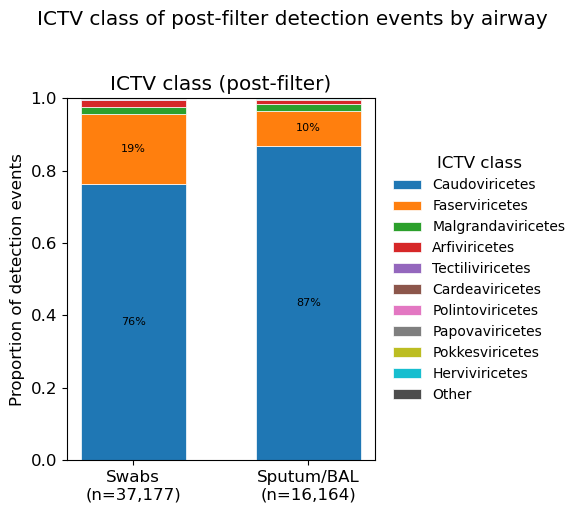

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results/cf_activity_ictv_taxonomy_pre_post.png
post-filter events with airway label: 53,341  (upper=37,177, lower=16,164)


rank,airway_label,taxon_plot,n,proportion
str,str,str,u32,f64
"""class""","""Sputum/BAL""","""Caudoviricetes""",14044,0.868844
"""class""","""Sputum/BAL""","""Faserviricetes""",1567,0.096944
"""class""","""Sputum/BAL""","""Malgrandaviricetes""",314,0.019426
"""class""","""Sputum/BAL""","""Arfiviricetes""",150,0.00928
"""class""","""Sputum/BAL""","""Cardeaviricetes""",48,0.00297
…,…,…,…,…
"""class""","""Swabs""","""Polintoviricetes""",19,0.000511
"""class""","""Swabs""","""Cardeaviricetes""",12,0.000323
"""class""","""Swabs""","""Papovaviricetes""",9,0.000242


In [70]:
### ICTV class of detected species (post-filter, by airway)
# Detection events (sample × species) after removing predicted-uninducible calls,
# split by upper vs lower airway. Pre-filter / removed stages are omitted here.
# ICTV family / host family / lifestyle are combined in the next cell.

sp_ictv = (
    uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .select(["species_cluster_id", "ictv_class", "ictv_family"])
    .unique("species_cluster_id")
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
)

if "all_detections" not in globals():
    all_detections = (
        coverm_df.filter(pl.col("breadth_ratio") > 0)
        .join(_id_ictv, left_on="contig_id", right_on="uhvdb_id", how="left")
        .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
        .sort(
            ["sample_id", "species_cluster_id", "breadth_ratio"],
            descending=[False, False, True],
        )
        .unique(["sample_id", "species_cluster_id"], keep="first")
        .select(["sample_id", "species_cluster_id", "ictv_class"])
    )

if "uninducible" not in globals():
    uninducible = (
        pl.from_pandas(
            scored[["sample_id", "species_cluster_id", "predicted_uninducible"]].copy()
        )
        .with_columns(pl.col("predicted_uninducible").cast(pl.Int64))
        .filter(pl.col("predicted_uninducible") == 1)
        .select(["sample_id", "species_cluster_id"])
    )

if "airway_labels" not in globals():
    airway_labels = (
        pl.read_csv(OUT_DIR / "cf_sample_type_airway3.tsv", separator="\t")
        .select(["sample_id", "airway_category"])
        .unique("sample_id")
    )

post_events = (
    all_detections.join(uninducible, on=["sample_id", "species_cluster_id"], how="anti")
    .join(sp_ictv, on="species_cluster_id", how="left")
    .join(airway_labels, on="sample_id", how="left")
    .filter(pl.col("airway_category").is_in(["upper_airway", "lower_airway"]))
    .with_columns(
        pl.col("airway_category")
        .replace({"upper_airway": "Swabs", "lower_airway": "Sputum/BAL"})
        .alias("airway_label")
    )
)


def overall_top(df: pl.DataFrame, col: str, top_n: int) -> list[str]:
    return (
        df.with_columns(pl.col(col).fill_null("Unclassified").alias(col))
        .group_by(col)
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
        .head(top_n)[col]
        .to_list()
    )


def taxonomy_props_by_airway(
    df: pl.DataFrame, col: str, top: list[str]
) -> pd.DataFrame:
    """Collapse to an overall top list + Other; proportions within each airway."""
    labeled = df.with_columns(
        pl.when(pl.col(col).fill_null("Unclassified").is_in(top))
        .then(pl.col(col).fill_null("Unclassified"))
        .otherwise(pl.lit("Other"))
        .alias("taxon_plot")
    )
    return (
        labeled.group_by(["airway_label", "taxon_plot"])
        .agg(pl.len().alias("n"))
        .with_columns(
            (pl.col("n") / pl.col("n").sum().over("airway_label")).alias("proportion")
        )
        .to_pandas()
    )


class_order = overall_top(post_events, "ictv_class", 10) + ["Other"]
airway_order = ["Swabs", "Sputum/BAL"]
class_props = taxonomy_props_by_airway(post_events, "ictv_class", class_order[:-1])


def stacked_taxonomy_airway(ax, props_df, order, airway_order, title):
    wide = (
        props_df.pivot(index="airway_label", columns="taxon_plot", values="proportion")
        .reindex(index=airway_order, columns=order)
        .fillna(0.0)
    )
    counts = (
        props_df.pivot(index="airway_label", columns="taxon_plot", values="n")
        .reindex(index=airway_order, columns=order)
        .fillna(0)
        .astype(int)
    )
    n_colors = max(len([t for t in order if t != "Other"]), 1)
    palette = sns.color_palette("tab10", n_colors=n_colors)
    color_map = {t: palette[i] for i, t in enumerate([x for x in order if x != "Other"])}
    color_map["Other"] = "#4d4d4d"
    color_map["Unclassified"] = "#9e9e9e"

    bottom = np.zeros(len(airway_order))
    x = np.arange(len(airway_order))
    for taxon in order:
        vals = wide[taxon].to_numpy() if taxon in wide.columns else np.zeros(len(airway_order))
        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.6,
            label=taxon if taxon is not None else "NA",
            color=color_map.get(taxon, "#cccccc"),
            edgecolor="white",
            linewidth=0.5,
        )
        for i, v in enumerate(vals):
            if v >= 0.05:
                ax.text(
                    x[i],
                    bottom[i] + v / 2,
                    f"{v:.0%}",
                    ha="center",
                    va="center",
                    fontsize=8,
                )
        bottom = bottom + vals

    n_map = counts.sum(axis=1).to_dict()
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{s}\n(n={int(n_map.get(s, 0)):,})" for s in airway_order]
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Proportion of detection events")
    ax.set_title(title)
    return color_map


fig, ax = plt.subplots(figsize=(6, 5))
stacked_taxonomy_airway(
    ax,
    class_props,
    class_order,
    airway_order,
    "ICTV class (post-filter)",
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    labels,
    title="ICTV class",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=10,
)

fig.suptitle(
    "ICTV class of post-filter detection events by airway",
    y=1.02,
)
fig.tight_layout()

ictv_png = OUT_DIR / "cf_activity_ictv_taxonomy_pre_post.png"
fig.savefig(ictv_png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", ictv_png)
print(
    f"post-filter events with airway label: {post_events.height:,}  "
    f"(upper={post_events.filter(pl.col('airway_label') == 'Swabs').height:,}, "
    f"lower={post_events.filter(pl.col('airway_label') == 'Sputum/BAL').height:,})"
)

ictv_summary = (
    pl.from_pandas(class_props)
    .with_columns(pl.lit("class").alias("rank"))
    .select(["rank", "airway_label", "taxon_plot", "n", "proportion"])
    .sort(["airway_label", "n"], descending=[False, True])
)
ictv_summary


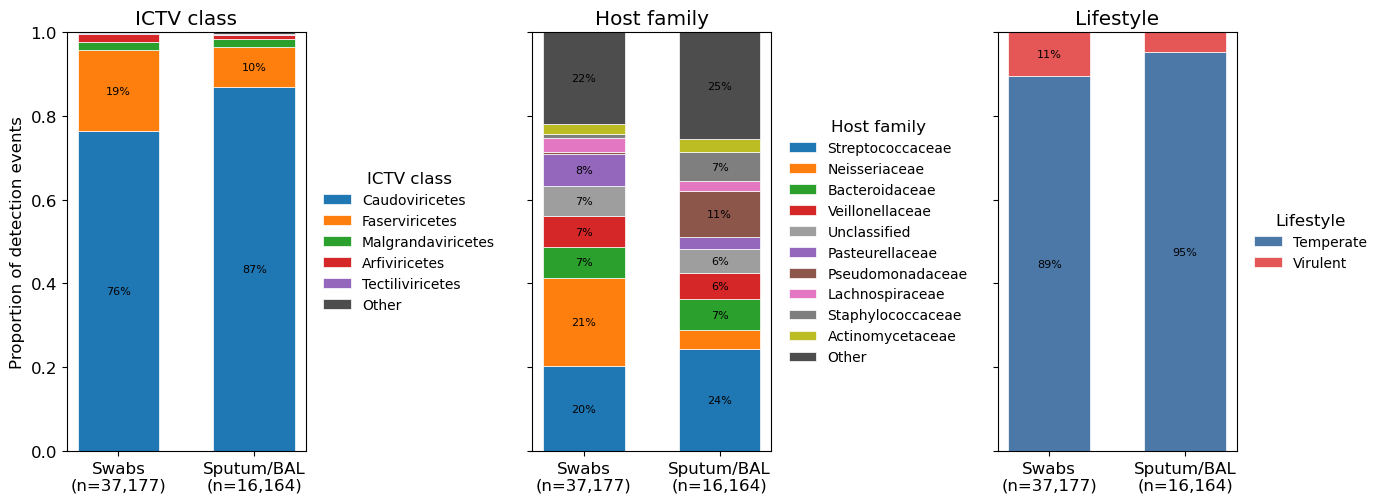

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results/cf_activity_ictv_host_lifestyle_pre_post.png
Also saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results/cf_activity_host_lifestyle_pre_post.png
post-filter events with airway label: 53,341  (upper=37,177, lower=16,164)


rank,airway_label,taxon_plot,n,proportion
str,str,str,u32,f64
"""host_family""","""Sputum/BAL""","""Other""",4117,0.254702
"""host_family""","""Sputum/BAL""","""Streptococcaceae""",3916,0.242267
"""host_family""","""Sputum/BAL""","""Pseudomonadaceae""",1752,0.108389
"""host_family""","""Sputum/BAL""","""Bacteroidaceae""",1182,0.073125
"""host_family""","""Sputum/BAL""","""Staphylococcaceae""",1113,0.068857
…,…,…,…,…
"""ictv_class""","""Swabs""","""Other""",52,0.001399
"""lifestyle""","""Sputum/BAL""","""Temperate""",15397,0.952549
"""lifestyle""","""Sputum/BAL""","""Virulent""",767,0.047451


In [71]:
### ICTV class, host family, and lifestyle (post-filter, by airway)
# Detection events (sample × species) after removing predicted-uninducible calls,
# split by upper vs lower airway.
# Panels (L→R): ICTV class (top 5 + Other), host family (top 10 + Other),
# lifestyle (temperate vs virulent).
# Temperate if >=1 signal: integrated provirus, BACPHLIP temperate (>0.5),
# or an integration-related gene (PHROG/Empathi).

# Keep ictv_class here too so later cells that reuse sp_ictv still work.
sp_ictv = (
    uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .select(["species_cluster_id", "ictv_class", "ictv_family"])
    .unique("species_cluster_id")
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
)

# Host family from species rep; lifestyle signals from all genomovars in the species.
# Schema must stay host_family/lifestyle-only for downstream cells that join sp_ictv separately.
sp_host_life = uhvdb_full.select(
    [
        "species_cluster_id",
        "seq_name",
        "seqhash_rep",
        "host_lineage",
        "temperate",
        "integration_status",
        "phrog_integration_excision",
        "empathi_integration",
    ]
).with_columns(pl.col("species_cluster_id").cast(pl.Int64))

sp_annot = (
    sp_host_life.group_by("species_cluster_id")
    .agg(
        [
            pl.col("host_lineage")
            .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
            .first()
            .alias("host_lineage"),
            (pl.col("integration_status") == "integrated").any().alias("has_integrated"),
            (pl.col("temperate") > 0.5).any().alias("has_bacphlip_temperate"),
            (
                (pl.col("phrog_integration_excision").fill_null(0) > 0)
                | (pl.col("empathi_integration").fill_null(0) > 0)
            )
            .any()
            .alias("has_integration_gene"),
        ]
    )
    .with_columns(
        [
            pl.col("host_lineage")
            .cast(pl.Utf8)
            .str.extract(r"f__([^;|]+)", 1)
            .fill_null("Unclassified")
            .alias("host_family"),
            pl.when(
                pl.col("has_integrated")
                | pl.col("has_bacphlip_temperate")
                | pl.col("has_integration_gene")
            )
            .then(pl.lit("Temperate"))
            .otherwise(pl.lit("Virulent"))
            .alias("lifestyle"),
        ]
    )
    .select(["species_cluster_id", "host_family", "lifestyle"])
)

sp_annot_plot = sp_annot.join(sp_ictv, on="species_cluster_id", how="left")

if "all_detections" not in globals():
    all_detections = (
        coverm_df.filter(pl.col("breadth_ratio") > 0)
        .join(_id_ictv, left_on="contig_id", right_on="uhvdb_id", how="left")
        .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
        .sort(
            ["sample_id", "species_cluster_id", "breadth_ratio"],
            descending=[False, False, True],
        )
        .unique(["sample_id", "species_cluster_id"], keep="first")
        .select(["sample_id", "species_cluster_id", "ictv_class"])
    )

if "uninducible" not in globals():
    uninducible = (
        pl.from_pandas(
            scored[["sample_id", "species_cluster_id", "predicted_uninducible"]].copy()
        )
        .with_columns(pl.col("predicted_uninducible").cast(pl.Int64))
        .filter(pl.col("predicted_uninducible") == 1)
        .select(["sample_id", "species_cluster_id"])
    )

if "airway_labels" not in globals():
    airway_labels = (
        pl.read_csv(OUT_DIR / "cf_sample_type_airway3.tsv", separator="\t")
        .select(["sample_id", "airway_category"])
        .unique("sample_id")
    )

post_events = (
    all_detections.join(uninducible, on=["sample_id", "species_cluster_id"], how="anti")
    .join(sp_annot_plot, on="species_cluster_id", how="left")
    .join(airway_labels, on="sample_id", how="left")
    .filter(pl.col("airway_category").is_in(["upper_airway", "lower_airway"]))
    .with_columns(
        pl.col("airway_category")
        .replace({"upper_airway": "Swabs", "lower_airway": "Sputum/BAL"})
        .alias("airway_label")
    )
)


def overall_top(df: pl.DataFrame, col: str, top_n: int) -> list[str]:
    return (
        df.with_columns(pl.col(col).fill_null("Unclassified").alias(col))
        .group_by(col)
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
        .head(top_n)[col]
        .to_list()
    )


def taxonomy_props_by_airway(
    df: pl.DataFrame, col: str, top: list[str]
) -> pd.DataFrame:
    """Collapse using an overall top list (+ Other); proportions within each airway."""
    labeled = df.with_columns(
        pl.when(pl.col(col).fill_null("Unclassified").is_in(top))
        .then(pl.col(col).fill_null("Unclassified"))
        .otherwise(pl.lit("Other"))
        .alias("taxon_plot")
    )
    return (
        labeled.group_by(["airway_label", "taxon_plot"])
        .agg(pl.len().alias("n"))
        .with_columns(
            (pl.col("n") / pl.col("n").sum().over("airway_label")).alias("proportion")
        )
        .to_pandas()
    )


airway_order = ["Swabs", "Sputum/BAL"]
lifestyle_order = ["Temperate", "Virulent"]
class_order = overall_top(post_events, "ictv_class", 5) + ["Other"]
host_order = overall_top(post_events, "host_family", 10) + ["Other"]

class_props = taxonomy_props_by_airway(post_events, "ictv_class", class_order[:-1])
host_props = taxonomy_props_by_airway(post_events, "host_family", host_order[:-1])
life_props = taxonomy_props_by_airway(post_events, "lifestyle", lifestyle_order)


def stacked_taxonomy_airway(ax, props_df, order, airway_order, title):
    wide = (
        props_df.pivot(index="airway_label", columns="taxon_plot", values="proportion")
        .reindex(index=airway_order, columns=order)
        .fillna(0.0)
    )
    counts = (
        props_df.pivot(index="airway_label", columns="taxon_plot", values="n")
        .reindex(index=airway_order, columns=order)
        .fillna(0)
        .astype(int)
    )
    named = [t for t in order if t not in ("Other", "Unclassified")]
    palette = sns.color_palette("tab10", n_colors=max(len(named), 1))
    color_map = {t: palette[i % len(palette)] for i, t in enumerate(named)}
    color_map["Other"] = "#4d4d4d"
    color_map["Unclassified"] = "#9e9e9e"
    color_map["Temperate"] = "#4C78A8"
    color_map["Virulent"] = "#E45756"

    bottom = np.zeros(len(airway_order))
    x = np.arange(len(airway_order))
    for taxon in order:
        vals = (
            wide[taxon].to_numpy()
            if taxon in wide.columns
            else np.zeros(len(airway_order))
        )
        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.6,
            label=taxon,
            color=color_map.get(taxon, "#cccccc"),
            edgecolor="white",
            linewidth=0.5,
        )
        for i, v in enumerate(vals):
            if v >= 0.05:
                ax.text(
                    x[i],
                    bottom[i] + v / 2,
                    f"{v:.0%}",
                    ha="center",
                    va="center",
                    fontsize=8,
                )
        bottom = bottom + vals

    n_map = counts.sum(axis=1).to_dict()
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{s}\n(n={int(n_map.get(s, 0)):,})" for s in airway_order]
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Proportion of detection events")
    ax.set_title(title)


fig, axes = plt.subplots(1, 3, figsize=(14, 5.2), sharey=True)
stacked_taxonomy_airway(axes[0], class_props, class_order, airway_order, "ICTV class")
stacked_taxonomy_airway(axes[1], host_props, host_order, airway_order, "Host family")
stacked_taxonomy_airway(axes[2], life_props, lifestyle_order, airway_order, "Lifestyle")
axes[1].set_ylabel("")
axes[2].set_ylabel("")

for ax, title in zip(axes, ["ICTV class", "Host family", "Lifestyle"]):
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles,
        labels,
        title=title,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=10,
    )

fig.tight_layout()

combo_png = OUT_DIR / "cf_activity_ictv_host_lifestyle_pre_post.png"
fig.savefig(combo_png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", combo_png)

host_life_png = OUT_DIR / "cf_activity_host_lifestyle_pre_post.png"
fig.savefig(host_life_png, dpi=150, bbox_inches="tight")
print("Also saved", host_life_png)
print(
    f"post-filter events with airway label: {post_events.height:,}  "
    f"(upper={post_events.filter(pl.col('airway_label') == 'Swabs').height:,}, "
    f"lower={post_events.filter(pl.col('airway_label') == 'Sputum/BAL').height:,})"
)

combo_summary = (
    pl.concat(
        [
            pl.from_pandas(class_props).with_columns(pl.lit("ictv_class").alias("rank")),
            pl.from_pandas(host_props).with_columns(pl.lit("host_family").alias("rank")),
            pl.from_pandas(life_props).with_columns(pl.lit("lifestyle").alias("rank")),
        ]
    )
    .select(["rank", "airway_label", "taxon_plot", "n", "proportion"])
    .sort(["rank", "airway_label", "n"], descending=[False, False, True])
)
combo_summary


Deep samples (read_depth >= 1e+08) used for high-prevalence species:
shape: (2, 2)
┌──────────────┬───────────┐
│ airway_label ┆ n_samples │
│ ---          ┆ ---       │
│ str          ┆ u32       │
╞══════════════╪═══════════╡
│ Sputum/BAL   ┆ 539       │
│ Swabs        ┆ 612       │
└──────────────┴───────────┘
Swabs: 32 high-prevalence species (≥10% of 612 deep samples; ≥62 samples)
Sputum/BAL: 10 high-prevalence species (≥10% of 539 deep samples; ≥54 samples)


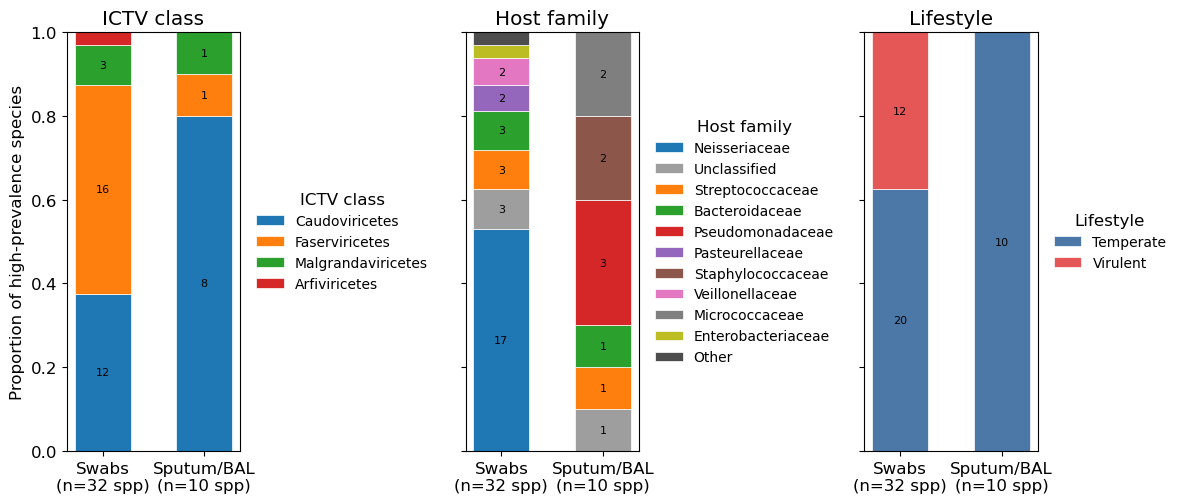

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results/cf_activity_high_prevalence_annotations.png
shape: (20, 7)
┌──────────────┬───────────────┬───────────┬────────────┬───────────────┬──────────────┬───────────┐
│ airway_label ┆ species_clust ┆ n_samples ┆ prevalence ┆ ictv_class    ┆ host_family  ┆ lifestyle │
│ ---          ┆ er_id         ┆ ---       ┆ ---        ┆ ---           ┆ ---          ┆ ---       │
│ str          ┆ ---           ┆ u32       ┆ f64        ┆ str           ┆ str          ┆ str       │
│              ┆ i64           ┆           ┆            ┆               ┆              ┆           │
╞══════════════╪═══════════════╪═══════════╪════════════╪═══════════════╪══════════════╪═══════════╡
│ Sputum/BAL   ┆ 3844          ┆ 151       ┆ 0.280148   ┆ Caudoviricete ┆ Streptococca ┆ Temperate │
│              ┆               ┆           ┆            ┆ s             ┆ ceae         ┆           │
│ Sputum/BAL   ┆

airway_label,species_cluster_id,n_samples,prevalence,ictv_class,host_family,lifestyle
str,i64,u32,f64,str,str,str
"""Sputum/BAL""",3844,151,0.280148,"""Caudoviricetes""","""Streptococcaceae""","""Temperate"""
"""Sputum/BAL""",30205,138,0.25603,"""Malgrandaviricetes""","""Bacteroidaceae""","""Temperate"""
"""Sputum/BAL""",61223,104,0.19295,"""Caudoviricetes""","""Pseudomonadaceae""","""Temperate"""
"""Sputum/BAL""",60946,86,0.159555,"""Faserviricetes""","""Pseudomonadaceae""","""Temperate"""
"""Sputum/BAL""",60786,84,0.155844,"""Caudoviricetes""","""Pseudomonadaceae""","""Temperate"""
…,…,…,…,…,…,…
"""Swabs""",64659,69,0.112745,"""Caudoviricetes""","""Streptococcaceae""","""Temperate"""
"""Swabs""",68936,68,0.111111,"""Faserviricetes""","""Neisseriaceae""","""Virulent"""
"""Swabs""",67308,67,0.109477,"""Faserviricetes""","""Neisseriaceae""","""Virulent"""


In [74]:
### High-prevalence species (≥10% of samples): ICTV class, host family, lifestyle
# Post-filter detections only (predicted-uninducible removed), split by upper/lower airway.
# Prevalence cohort = CoverM samples with read_depth >= 1e8 within each airway.
# Species detected in >= prev_thresh of samples within each airway cohort;
# show composition of those species by ICTV class, host family, and lifestyle.

prev_thresh = 0.1
DEPTH_MIN = 1e8

if "read_depth" not in globals():
    read_depth = (
        pl.read_csv(FIG_5 / "cf_metag_read_depth.txt.gz", separator="\t", has_header=False)
        .rename({"column_1": "sample_id", "column_2": "read_depth"})
    )

if "all_detections" not in globals():
    all_detections = (
        coverm_df.filter(pl.col("breadth_ratio") > 0)
        .join(_id_ictv, left_on="contig_id", right_on="uhvdb_id", how="left")
        .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
        .sort(
            ["sample_id", "species_cluster_id", "breadth_ratio"],
            descending=[False, False, True],
        )
        .unique(["sample_id", "species_cluster_id"], keep="first")
        .select(["sample_id", "species_cluster_id", "ictv_class"])
    )

if "uninducible" not in globals():
    uninducible = (
        pl.from_pandas(
            scored[["sample_id", "species_cluster_id", "predicted_uninducible"]].copy()
        )
        .with_columns(pl.col("predicted_uninducible").cast(pl.Int64))
        .filter(pl.col("predicted_uninducible") == 1)
        .select(["sample_id", "species_cluster_id"])
    )

if "airway_labels" not in globals():
    airway_labels = (
        pl.read_csv(OUT_DIR / "cf_sample_type_airway3.tsv", separator="\t")
        .select(["sample_id", "airway_category"])
        .unique("sample_id")
    )

if "sp_ictv" not in globals():
    sp_ictv = (
        uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep"))
        .select(["species_cluster_id", "ictv_class", "ictv_family"])
        .unique("species_cluster_id")
        .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
    )

if "sp_annot" not in globals():
    sp_host_life = uhvdb_full.select(
        [
            "species_cluster_id",
            "seq_name",
            "seqhash_rep",
            "host_lineage",
            "temperate",
            "integration_status",
            "phrog_integration_excision",
            "empathi_integration",
        ]
    ).with_columns(pl.col("species_cluster_id").cast(pl.Int64))
    sp_annot = (
        sp_host_life.group_by("species_cluster_id")
        .agg(
            [
                pl.col("host_lineage")
                .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
                .first()
                .alias("host_lineage"),
                (pl.col("integration_status") == "integrated").any().alias("has_integrated"),
                (pl.col("temperate") > 0.5).any().alias("has_bacphlip_temperate"),
                (
                    (pl.col("phrog_integration_excision").fill_null(0) > 0)
                    | (pl.col("empathi_integration").fill_null(0) > 0)
                )
                .any()
                .alias("has_integration_gene"),
            ]
        )
        .with_columns(
            [
                pl.col("host_lineage")
                .cast(pl.Utf8)
                .str.extract(r"f__([^;|]+)", 1)
                .fill_null("Unclassified")
                .alias("host_family"),
                pl.when(
                    pl.col("has_integrated")
                    | pl.col("has_bacphlip_temperate")
                    | pl.col("has_integration_gene")
                )
                .then(pl.lit("Temperate"))
                .otherwise(pl.lit("Virulent"))
                .alias("lifestyle"),
            ]
        )
        .select(["species_cluster_id", "host_family", "lifestyle"])
    )

airway_order = ["Swabs", "Sputum/BAL"]
deep_samples = (
    coverm_df.select("sample_id")
    .unique()
    .join(read_depth, on="sample_id", how="left")
    .join(airway_labels, on="sample_id", how="left")
    .filter(pl.col("read_depth") >= DEPTH_MIN)
    .filter(pl.col("airway_category").is_in(["upper_airway", "lower_airway"]))
    .with_columns(
        pl.col("airway_category")
        .replace({"upper_airway": "Swabs", "lower_airway": "Sputum/BAL"})
        .alias("airway_label")
    )
)

post_detections = (
    all_detections.join(uninducible, on=["sample_id", "species_cluster_id"], how="anti")
    .join(deep_samples.select(["sample_id", "airway_label"]), on="sample_id", how="inner")
)

airway_n = {
    str(r["airway_label"]): int(r["n"])
    for r in deep_samples.group_by("airway_label").agg(pl.len().alias("n")).iter_rows(named=True)
}
print(f"Deep samples (read_depth >= {DEPTH_MIN:.0e}) used for high-prevalence species:")
print(deep_samples.group_by("airway_label").agg(pl.len().alias("n_samples")).sort("airway_label"))

high_prev_parts = []
for airway, n_samp in airway_n.items():
    min_samples = max(1, int(np.ceil(prev_thresh * n_samp)))
    part = (
        post_detections.filter(pl.col("airway_label") == airway)
        .group_by("species_cluster_id")
        .agg(pl.col("sample_id").n_unique().alias("n_samples"))
        .with_columns((pl.col("n_samples") / n_samp).alias("prevalence"))
        .filter(pl.col("prevalence") >= prev_thresh)
        .with_columns(pl.lit(airway).alias("airway_label"))
    )
    high_prev_parts.append(part)
    print(
        f"{airway}: {part.height:,} high-prevalence species "
        f"(≥{prev_thresh:.0%} of {n_samp:,} deep samples; ≥{min_samples} samples)"
    )

high_prev = (
    pl.concat(high_prev_parts)
    .join(sp_ictv, on="species_cluster_id", how="left")
    .join(sp_annot, on="species_cluster_id", how="left")
    .with_columns(
        [
            pl.col("ictv_class").fill_null("Unclassified"),
            pl.col("host_family").fill_null("Unclassified"),
            pl.col("lifestyle").fill_null("Virulent"),
        ]
    )
)


def overall_top(df: pl.DataFrame, col: str, top_n: int) -> list[str]:
    return (
        df.group_by(col)
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
        .head(top_n)[col]
        .to_list()
    )


def category_props_by_airway(
    df: pl.DataFrame, col: str, order: list[str]
) -> pd.DataFrame:
    labeled = df.with_columns(
        pl.when(pl.col(col).is_in(order))
        .then(pl.col(col))
        .otherwise(pl.lit("Other"))
        .alias("cat")
    )
    return (
        labeled.group_by(["airway_label", "cat"])
        .agg(pl.len().alias("n"))
        .with_columns(
            (pl.col("n") / pl.col("n").sum().over("airway_label")).alias("proportion")
        )
        .to_pandas()
    )


def stacked_by_airway(ax, props_df, order, airway_order, title, ylabel=True):
    wide = (
        props_df.pivot(index="airway_label", columns="cat", values="proportion")
        .reindex(index=airway_order, columns=order)
        .fillna(0.0)
    )
    counts = (
        props_df.pivot(index="airway_label", columns="cat", values="n")
        .reindex(index=airway_order, columns=order)
        .fillna(0)
        .astype(int)
    )
    named = [c for c in order if c not in ("Other", "Unclassified")]
    pal = sns.color_palette("tab10", n_colors=max(len(named), 1))
    color_map = {c: pal[i % len(pal)] for i, c in enumerate(named)}
    color_map["Other"] = "#4d4d4d"
    color_map["Unclassified"] = "#9e9e9e"
    color_map["Temperate"] = "#4C78A8"
    color_map["Virulent"] = "#E45756"

    bottom = np.zeros(len(airway_order))
    x = np.arange(len(airway_order))
    for cat in order:
        vals = (
            wide[cat].to_numpy() if cat in wide.columns else np.zeros(len(airway_order))
        )
        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.55,
            label=cat,
            color=color_map.get(cat, "#cccccc"),
            edgecolor="white",
            linewidth=0.5,
        )
        for i, v in enumerate(vals):
            if v >= 0.04:
                n = int(counts.iloc[i][cat]) if cat in counts.columns else 0
                ax.text(x[i], bottom[i] + v / 2, f"{n}", ha="center", va="center", fontsize=8)
        bottom = bottom + vals

    n_map = counts.sum(axis=1).to_dict()
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{s}\n(n={int(n_map.get(s, 0))} spp)" for s in airway_order]
    )
    ax.set_ylim(0, 1)
    if ylabel:
        ax.set_ylabel("Proportion of high-prevalence species")
    ax.set_title(title)
    ax.legend(
        title=title,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=10,
    )


ictv_order = overall_top(high_prev, "ictv_class", 5)
if "Other" not in ictv_order:
    # include Other only if needed after collapse
    pass
ictv_order = ictv_order + ["Other"]
host_order_hp = overall_top(high_prev, "host_family", 10) + ["Other"]
life_order_hp = ["Temperate", "Virulent"]

ictv_props = category_props_by_airway(high_prev, "ictv_class", ictv_order[:-1])
host_props_hp = category_props_by_airway(high_prev, "host_family", host_order_hp[:-1])
life_props_hp = category_props_by_airway(high_prev, "lifestyle", life_order_hp)

# Drop trailing Other from order if unused
def _trim_other(order, props_df):
    if "Other" in order and (
        "Other" not in props_df["cat"].values
        or props_df.loc[props_df["cat"] == "Other", "n"].sum() == 0
    ):
        return [c for c in order if c != "Other"]
    return order


ictv_order = _trim_other(ictv_order, ictv_props)
host_order_hp = _trim_other(host_order_hp, host_props_hp)

fig, axes = plt.subplots(1, 3, figsize=(12, 5.2), sharey=True)
stacked_by_airway(axes[0], ictv_props, ictv_order, airway_order, "ICTV class")
stacked_by_airway(
    axes[1], host_props_hp, host_order_hp, airway_order, "Host family", ylabel=False
)
stacked_by_airway(
    axes[2], life_props_hp, life_order_hp, airway_order, "Lifestyle", ylabel=False
)

fig.tight_layout()

hp_png = OUT_DIR / "cf_activity_high_prevalence_annotations.png"
fig.savefig(hp_png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", hp_png)

high_prev_summary = high_prev.select(
    [
        "airway_label",
        "species_cluster_id",
        "n_samples",
        "prevalence",
        "ictv_class",
        "host_family",
        "lifestyle",
    ]
).sort(["airway_label", "prevalence"], descending=[False, True])
print(high_prev_summary.head(20))
high_prev_summary


High-prevalence families: 53 (≥10% of 1,807 samples; ≥181 samples)


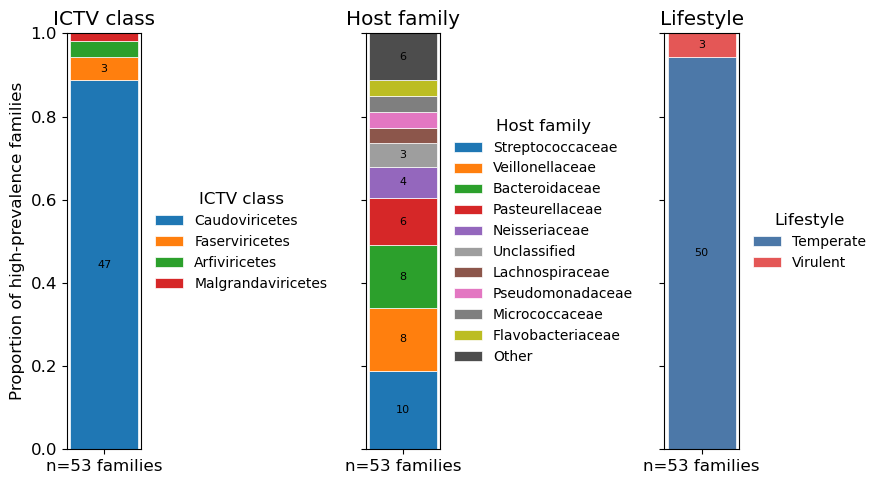

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results/cf_activity_high_prevalence_family_annotations.png
shape: (20, 7)
┌────────────────┬───────────┬────────────┬───────────┬────────────────┬───────────────┬───────────┐
│ family_cluster ┆ n_samples ┆ prevalence ┆ n_species ┆ ictv_class     ┆ host_family   ┆ lifestyle │
│ _id            ┆ ---       ┆ ---        ┆ ---       ┆ ---            ┆ ---           ┆ ---       │
│ ---            ┆ u32       ┆ f64        ┆ u32       ┆ str            ┆ str           ┆ str       │
│ i64            ┆           ┆            ┆           ┆                ┆               ┆           │
╞════════════════╪═══════════╪════════════╪═══════════╪════════════════╪═══════════════╪═══════════╡
│ 20             ┆ 1290      ┆ 0.71389    ┆ 2179      ┆ Caudoviricetes ┆ Streptococcac ┆ Temperate │
│                ┆           ┆            ┆           ┆                ┆ eae           ┆           │
│ 3      

family_cluster_id,n_samples,prevalence,n_species,ictv_class,host_family,lifestyle
i64,u32,f64,u32,str,str,str
20,1290,0.71389,2179,"""Caudoviricetes""","""Streptococcaceae""","""Temperate"""
3,912,0.504704,4673,"""Caudoviricetes""","""Streptococcaceae""","""Temperate"""
1,898,0.496956,8418,"""Caudoviricetes""","""Streptococcaceae""","""Temperate"""
18,849,0.46984,2235,"""Caudoviricetes""","""Staphylococcaceae""","""Temperate"""
41,770,0.426121,1058,"""Caudoviricetes""","""Bacteroidaceae""","""Temperate"""
…,…,…,…,…,…,…
183,203,0.112341,225,"""Caudoviricetes""","""Veillonellaceae""","""Temperate"""
190,190,0.105147,211,"""Caudoviricetes""","""Flavobacteriaceae""","""Temperate"""
118,188,0.10404,404,"""Caudoviricetes""","""Neisseriaceae""","""Temperate"""


In [76]:
### High-prevalence families (≥10% of samples): ICTV class, host family, lifestyle
# Family = UHVDB family_cluster_id. Prevalence = samples with >=1 member species detected.
# Annotations are the consensus (mode) across species reps in each family.

n_samples_total = int(coverm_df["sample_id"].n_unique())
prev_thresh = 0.1
min_samples = max(1, int(np.ceil(prev_thresh * n_samples_total)))

if "all_detections" not in globals():
    all_detections = (
        coverm_df.filter(pl.col("breadth_ratio") > 0)
        .join(_id_ictv, left_on="contig_id", right_on="uhvdb_id", how="left")
        .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
        .sort(
            ["sample_id", "species_cluster_id", "breadth_ratio"],
            descending=[False, False, True],
        )
        .unique(["sample_id", "species_cluster_id"], keep="first")
        .select(["sample_id", "species_cluster_id", "ictv_class"])
    )

if "sp_tax" not in globals():
    sp_tax = (
        uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep"))
        .select(["species_cluster_id", "genus_cluster_id", "family_cluster_id"])
        .unique("species_cluster_id")
        .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
    )

if "sp_ictv" not in globals():
    sp_ictv = (
        uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep"))
        .select(["species_cluster_id", "ictv_class", "ictv_family"])
        .unique("species_cluster_id")
        .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
    )

if "sp_annot" not in globals():
    sp_host_life = uhvdb_full.select(
        [
            "species_cluster_id",
            "seq_name",
            "seqhash_rep",
            "host_lineage",
            "temperate",
            "integration_status",
            "phrog_integration_excision",
            "empathi_integration",
        ]
    ).with_columns(pl.col("species_cluster_id").cast(pl.Int64))
    sp_annot = (
        sp_host_life.group_by("species_cluster_id")
        .agg(
            [
                pl.col("host_lineage")
                .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
                .first()
                .alias("host_lineage"),
                (pl.col("integration_status") == "integrated").any().alias("has_integrated"),
                (pl.col("temperate") > 0.5).any().alias("has_bacphlip_temperate"),
                (
                    (pl.col("phrog_integration_excision").fill_null(0) > 0)
                    | (pl.col("empathi_integration").fill_null(0) > 0)
                )
                .any()
                .alias("has_integration_gene"),
            ]
        )
        .with_columns(
            [
                pl.col("host_lineage")
                .cast(pl.Utf8)
                .str.extract(r"f__([^;|]+)", 1)
                .fill_null("Unclassified")
                .alias("host_family"),
                pl.when(
                    pl.col("has_integrated")
                    | pl.col("has_bacphlip_temperate")
                    | pl.col("has_integration_gene")
                )
                .then(pl.lit("Temperate"))
                .otherwise(pl.lit("Virulent"))
                .alias("lifestyle"),
            ]
        )
        .select(["species_cluster_id", "host_family", "lifestyle"])
    )

# Species-level labels joined to family membership
sp_family_annot = (
    sp_tax.select(["species_cluster_id", "family_cluster_id"])
    .join(sp_ictv.select(["species_cluster_id", "ictv_class"]), on="species_cluster_id", how="left")
    .join(sp_annot, on="species_cluster_id", how="left")
    .with_columns(
        [
            pl.col("ictv_class").fill_null("Unclassified"),
            pl.col("host_family").fill_null("Unclassified"),
            pl.col("lifestyle").fill_null("Virulent"),
        ]
    )
    .filter(pl.col("family_cluster_id").is_not_null())
)

# Consensus annotations within each family (mode of member species)
fam_annot = (
    sp_family_annot.group_by("family_cluster_id")
    .agg(
        [
            pl.len().alias("n_species"),
            pl.col("ictv_class").mode().first().alias("ictv_class"),
            pl.col("host_family").mode().first().alias("host_family"),
            pl.col("lifestyle").mode().first().alias("lifestyle"),
        ]
    )
)

# Family prevalence: samples with any member species detected
fam_detections = (
    all_detections.join(sp_tax, on="species_cluster_id", how="left")
    .filter(pl.col("family_cluster_id").is_not_null())
    .group_by("family_cluster_id")
    .agg(pl.col("sample_id").n_unique().alias("n_samples"))
    .with_columns((pl.col("n_samples") / n_samples_total).alias("prevalence"))
)

high_prev_fam = (
    fam_detections.filter(pl.col("prevalence") >= prev_thresh)
    .join(fam_annot, on="family_cluster_id", how="left")
    .with_columns(
        [
            pl.col("ictv_class").fill_null("Unclassified"),
            pl.col("host_family").fill_null("Unclassified"),
            pl.col("lifestyle").fill_null("Virulent"),
        ]
    )
)

print(
    f"High-prevalence families: {high_prev_fam.height:,} "
    f"(≥{prev_thresh:.0%} of {n_samples_total:,} samples; ≥{min_samples} samples)"
)


def category_props(df: pl.DataFrame, col: str, top_n: int | None = None, fixed_order=None):
    if fixed_order is not None:
        order = list(fixed_order)
        labeled = df.with_columns(
            pl.when(pl.col(col).is_in(order))
            .then(pl.col(col))
            .otherwise(pl.lit("Other"))
            .alias("cat")
        )
    else:
        top = (
            df.group_by(col)
            .agg(pl.len().alias("n"))
            .sort("n", descending=True)
            .head(top_n)[col]
            .to_list()
        )
        labeled = df.with_columns(
            pl.when(pl.col(col).is_in(top))
            .then(pl.col(col))
            .otherwise(pl.lit("Other"))
            .alias("cat")
        )
        order = top[:]
        if labeled.filter(pl.col("cat") == "Other").height and "Other" not in order:
            order.append("Other")

    props = (
        labeled.group_by("cat")
        .agg(pl.len().alias("n"))
        .with_columns((pl.col("n") / pl.col("n").sum()).alias("proportion"))
        .to_pandas()
        .set_index("cat")
        .reindex(order)
        .fillna(0)
    )
    return props, order


def stacked_single(ax, props, order, title, ylab="Proportion of high-prevalence families"):
    named = [c for c in order if c not in ("Other", "Unclassified")]
    pal = sns.color_palette("tab10", n_colors=max(len(named), 1))
    color_map = {c: pal[i % len(pal)] for i, c in enumerate(named)}
    color_map["Other"] = "#4d4d4d"
    color_map["Unclassified"] = "#9e9e9e"
    color_map["Temperate"] = "#4C78A8"
    color_map["Virulent"] = "#E45756"

    bottom = 0.0
    for cat in order:
        v = float(props.loc[cat, "proportion"]) if cat in props.index else 0.0
        n = int(props.loc[cat, "n"]) if cat in props.index else 0
        ax.bar(
            0,
            v,
            bottom=bottom,
            width=0.55,
            label=cat,
            color=color_map.get(cat, "#cccccc"),
            edgecolor="white",
            linewidth=0.5,
        )
        if v >= 0.04:
            ax.text(0, bottom + v / 2, f"{n}", ha="center", va="center", fontsize=8)
        bottom += v

    ax.set_xticks([0])
    ax.set_xticklabels([f"n={int(props['n'].sum()):,} families"])
    ax.set_ylim(0, 1)
    if ylab:
        ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.legend(
        title=title,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=10,
    )


ictv_props_f, ictv_order_f = category_props(high_prev_fam, "ictv_class", top_n=5)
host_props_f, host_order_f = category_props(high_prev_fam, "host_family", top_n=10)
life_props_f, life_order_f = category_props(
    high_prev_fam, "lifestyle", fixed_order=["Temperate", "Virulent"]
)

fig, axes = plt.subplots(1, 3, figsize=(9, 5), sharey=True)
stacked_single(axes[0], ictv_props_f, ictv_order_f, "ICTV class")
stacked_single(axes[1], host_props_f, host_order_f, "Host family", ylab=None)
stacked_single(axes[2], life_props_f, life_order_f, "Lifestyle", ylab=None)


fig.tight_layout()

hpf_png = OUT_DIR / "cf_activity_high_prevalence_family_annotations.png"
fig.savefig(hpf_png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", hpf_png)

high_prev_fam_summary = (
    high_prev_fam.select(
        [
            "family_cluster_id",
            "n_samples",
            "prevalence",
            "n_species",
            "ictv_class",
            "host_family",
            "lifestyle",
        ]
    )
    .sort("prevalence", descending=True)
)
print(high_prev_fam_summary.head(20))
high_prev_fam_summary

In [78]:
### Most prevalent eukaryotic virus species
# Eukaryotic-host viruses: ICTV class assigned and not in prokaryote-only classes
# (same definition as figure_5_exploratory). Prevalence = fraction of CoverM samples
# with the species detected (breadth_ratio > 0, species rep).
# Mean/median breadth_ratio are over detection events (one per sample × species).

PROKARYOTE_ONLY_ICTV_CLASSES = {
    "Caudoviricetes",
    "Malgrandaviricetes",  # Microviridae
    "Tectiliviricetes",  # Tectiviridae
    "Leviviricetes",  # Fiersviridae
    "Faserviricetes",  # Inoviridae
}

n_samples_total = int(coverm_df["sample_id"].n_unique())

sp_euk_meta = (
    uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .select(
        [
            "species_cluster_id",
            "ictv_class",
            "ictv_family",
            "ictv_genus",
            "ictv_species",
        ]
    )
    .unique("species_cluster_id")
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
    .filter(
        pl.col("ictv_class").is_not_null()
        & ~pl.col("ictv_class").is_in(list(PROKARYOTE_ONLY_ICTV_CLASSES))
    )
)

# Species-rep detections with breadth for eukaryotic viruses
euk_detections = (
    coverm_df.filter(pl.col("breadth_ratio") > 0)
    .join(_id_ictv, left_on="contig_id", right_on="uhvdb_id", how="left")
    .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .sort(
        ["sample_id", "species_cluster_id", "breadth_ratio"],
        descending=[False, False, True],
    )
    .unique(["sample_id", "species_cluster_id"], keep="first")
    .select(["sample_id", "species_cluster_id", "breadth_ratio"])
    .join(sp_euk_meta, on="species_cluster_id", how="inner")
)

euk_prevalence = (
    euk_detections.group_by(
        [
            "species_cluster_id",
            "ictv_class",
            "ictv_family",
            "ictv_genus",
            "ictv_species",
        ]
    )
    .agg(
        [
            pl.col("sample_id").n_unique().alias("n_samples"),
            pl.col("breadth_ratio").mean().alias("mean_breadth_ratio"),
            pl.col("breadth_ratio").median().alias("median_breadth_ratio"),
        ]
    )
    .with_columns((pl.col("n_samples") / n_samples_total).alias("prevalence"))
    .select(
        [
            "species_cluster_id",
            "ictv_class",
            "ictv_family",
            "ictv_genus",
            "ictv_species",
            "n_samples",
            "prevalence",
            "mean_breadth_ratio",
            "median_breadth_ratio",
        ]
    )
    .sort("prevalence", descending=True)
)

print(
    f"Eukaryotic virus species detected: {euk_prevalence.height:,} "
    f"(of {n_samples_total:,} samples)"
)
print("\nMost prevalent eukaryotic virus species:")
euk_prevalence.head(10)


Eukaryotic virus species detected: 105 (of 1,807 samples)

Most prevalent eukaryotic virus species:


species_cluster_id,ictv_class,ictv_family,ictv_genus,ictv_species,n_samples,prevalence,mean_breadth_ratio,median_breadth_ratio
i64,str,str,str,str,u32,f64,f64,f64
57560,"""Arfiviricetes""","""Kanorauviridae""","""Kaiwanvirus""","""Kaiwanvirus sewoxi""",278,0.153846,0.716418,0.746652
53999,"""Arfiviricetes""","""Gandrviridae""","""Satyrivirus""","""Satyrivirus cordulis""",75,0.041505,0.850191,0.830505
71806,"""Arfiviricetes""",null,null,null,66,0.036525,0.845628,0.842938
20265,"""Arfiviricetes""",null,null,null,60,0.033204,0.961409,0.993448
58107,"""Arfiviricetes""","""Gandrviridae""","""Satyrivirus""","""Satyrivirus cordulis""",48,0.026563,0.925171,0.913795
90213,"""Arfiviricetes""",null,null,null,45,0.024903,0.684754,0.701527
72490,"""Arfiviricetes""",null,null,null,41,0.02269,0.735605,0.737646
53666,"""Arfiviricetes""",null,null,null,38,0.021029,0.754595,0.761726
30375,"""Arfiviricetes""",null,null,null,36,0.019923,0.913132,0.995296


Deep samples (read_depth >= 1e+08):
shape: (2, 2)
┌──────────────┬───────────┐
│ airway_label ┆ n_samples │
│ ---          ┆ ---       │
│ str          ┆ u32       │
╞══════════════╪═══════════╡
│ Sputum/BAL   ┆ 539       │
│ Swabs        ┆ 612       │
└──────────────┴───────────┘

ICTV class prevalence by airway:
shape: (13, 5)
┌──────────────────┬────────────────────┬────────────┬──────────────┬──────────────────┐
│ ictv_class       ┆ n_samples_detected ┆ prevalence ┆ airway_label ┆ n_samples_cohort │
│ ---              ┆ ---                ┆ ---        ┆ ---          ┆ ---              │
│ str              ┆ u32                ┆ f64        ┆ str          ┆ i32              │
╞══════════════════╪════════════════════╪════════════╪══════════════╪══════════════════╡
│ Arfiviricetes    ┆ 124                ┆ 23.005566  ┆ Sputum/BAL   ┆ 539              │
│ Cardeaviricetes  ┆ 19                 ┆ 3.525046   ┆ Sputum/BAL   ┆ 539              │
│ Papovaviricetes  ┆ 8                  ┆ 1.48

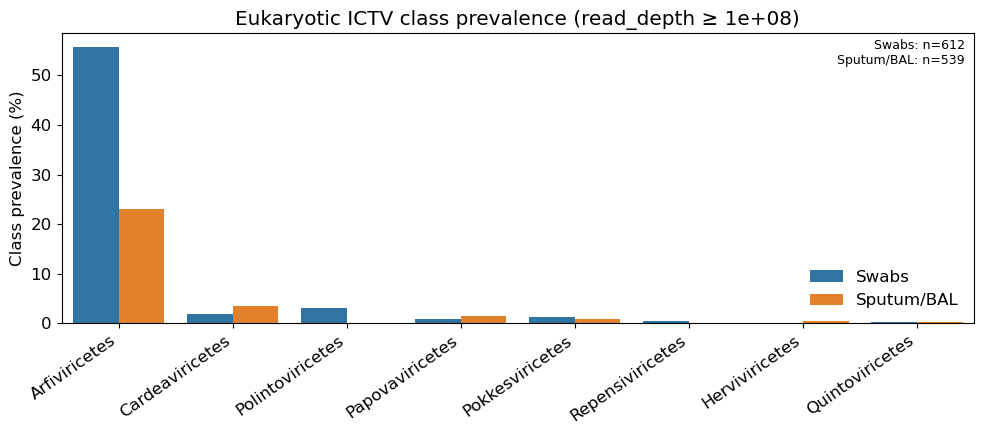

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results/cf_activity_euk_ictv_class_prevalence_by_airway.png


ictv_class,n_samples_detected,prevalence,airway_label,n_samples_cohort
str,u32,f64,str,i32
"""Arfiviricetes""",124,23.005566,"""Sputum/BAL""",539
"""Cardeaviricetes""",19,3.525046,"""Sputum/BAL""",539
"""Papovaviricetes""",8,1.48423,"""Sputum/BAL""",539
"""Pokkesviricetes""",5,0.927644,"""Sputum/BAL""",539
"""Herviviricetes""",2,0.371058,"""Sputum/BAL""",539
…,…,…,…,…
"""Cardeaviricetes""",11,1.797386,"""Swabs""",612
"""Pokkesviricetes""",8,1.30719,"""Swabs""",612
"""Papovaviricetes""",5,0.816993,"""Swabs""",612


In [79]:
### Eukaryotic ICTV class prevalence by sample type (deep samples)
# Prevalence = (# deep samples with ≥1 detection of the ICTV class)
#            / (# deep CoverM samples in that airway) * 100.
# Cohort = read_depth >= 1e8, split into Swabs vs Sputum/BAL.
# Uses eukaryotic-host virus definition from the previous cell.

DEPTH_MIN = 1e8

if "euk_detections" not in globals():
    raise RuntimeError("Run the eukaryotic virus prevalence cell first to build euk_detections")

if "read_depth" not in globals():
    read_depth = (
        pl.read_csv(FIG_5 / "cf_metag_read_depth.txt.gz", separator="\t", has_header=False)
        .rename({"column_1": "sample_id", "column_2": "read_depth"})
    )

if "airway_labels" not in globals():
    airway_labels = (
        pl.read_csv(OUT_DIR / "cf_sample_type_airway3.tsv", separator="\t")
        .select(["sample_id", "airway_category"])
        .unique("sample_id")
    )

airway_order = ["Swabs", "Sputum/BAL"]
deep_samples = (
    coverm_df.select("sample_id")
    .unique()
    .join(read_depth, on="sample_id", how="left")
    .join(airway_labels, on="sample_id", how="left")
    .filter(pl.col("read_depth") >= DEPTH_MIN)
    .filter(pl.col("airway_category").is_in(["upper_airway", "lower_airway"]))
    .with_columns(
        pl.col("airway_category")
        .replace({"upper_airway": "Swabs", "lower_airway": "Sputum/BAL"})
        .alias("airway_label")
    )
)

airway_n = {
    str(r["airway_label"]): int(r["n"])
    for r in deep_samples.group_by("airway_label").agg(pl.len().alias("n")).iter_rows(named=True)
}
print(f"Deep samples (read_depth >= {DEPTH_MIN:.0e}):")
print(deep_samples.group_by("airway_label").agg(pl.len().alias("n_samples")).sort("airway_label"))

euk_deep = euk_detections.join(
    deep_samples.select(["sample_id", "airway_label"]),
    on="sample_id",
    how="inner",
)

class_prev_rows = []
for airway, n_samp in airway_n.items():
    class_prev_rows.append(
        euk_deep.filter(pl.col("airway_label") == airway)
        .group_by("ictv_class")
        .agg(pl.col("sample_id").n_unique().alias("n_samples_detected"))
        .with_columns(
            [
                (pl.col("n_samples_detected") * 100 / n_samp).alias("prevalence"),
                pl.lit(airway).alias("airway_label"),
                pl.lit(n_samp).alias("n_samples_cohort"),
            ]
        )
    )

euk_class_prevalence = pl.concat(class_prev_rows).sort(
    ["airway_label", "prevalence"], descending=[False, True]
)
print("\nICTV class prevalence by airway:")
print(euk_class_prevalence)

# Plot top classes by max prevalence across airways
top_classes = (
    euk_class_prevalence.group_by("ictv_class")
    .agg(pl.col("prevalence").max().alias("max_prev"))
    .sort("max_prev", descending=True)
    .head(10)["ictv_class"]
    .to_list()
)

plot_df = (
    euk_class_prevalence.filter(pl.col("ictv_class").is_in(top_classes))
    .to_pandas()
)
plot_df["ictv_class"] = pd.Categorical(plot_df["ictv_class"], categories=top_classes, ordered=True)
plot_df["airway_label"] = pd.Categorical(
    plot_df["airway_label"], categories=airway_order, ordered=True
)

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(
    data=plot_df,
    x="ictv_class",
    y="prevalence",
    hue="airway_label",
    hue_order=airway_order,
    palette={"Swabs": "#1f77b4", "Sputum/BAL": "#ff7f0e"},
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("Class prevalence (%)")
ax.set_title(
    f"Eukaryotic ICTV class prevalence (read_depth ≥ {DEPTH_MIN:.0e})"
)
ax.tick_params(axis="x", rotation=35)
for label in ax.get_xticklabels():
    label.set_ha("right")
ax.legend(title="", frameon=False)
# Annotate cohort sizes in legend-style note
ax.text(
    0.99,
    0.98,
    "\n".join([f"{a}: n={airway_n.get(a, 0)}" for a in airway_order]),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
)
fig.tight_layout()

euk_class_png = OUT_DIR / "cf_activity_euk_ictv_class_prevalence_by_airway.png"
fig.savefig(euk_class_png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", euk_class_png)
euk_class_prevalence


Class tax_abund mean/median among detections (deep samples):
shape: (13, 5)
┌──────────────┬──────────────────┬────────────────────┬────────────────┬──────────────────┐
│ airway_label ┆ ictv_class       ┆ n_samples_detected ┆ mean_tax_abund ┆ median_tax_abund │
│ ---          ┆ ---              ┆ ---                ┆ ---            ┆ ---              │
│ str          ┆ str              ┆ u32                ┆ f64            ┆ f64              │
╞══════════════╪══════════════════╪════════════════════╪════════════════╪══════════════════╡
│ Sputum/BAL   ┆ Arfiviricetes    ┆ 124                ┆ 0.973061       ┆ 0.5373           │
│ Swabs        ┆ Arfiviricetes    ┆ 341                ┆ 5.809348       ┆ 0.9357           │
│ Sputum/BAL   ┆ Cardeaviricetes  ┆ 19                 ┆ 20.083937      ┆ 2.5348           │
│ Swabs        ┆ Cardeaviricetes  ┆ 11                 ┆ 0.522127       ┆ 0.1061           │
│ Sputum/BAL   ┆ Herviviricetes   ┆ 2                  ┆ 0.25735        ┆ 0.25735      

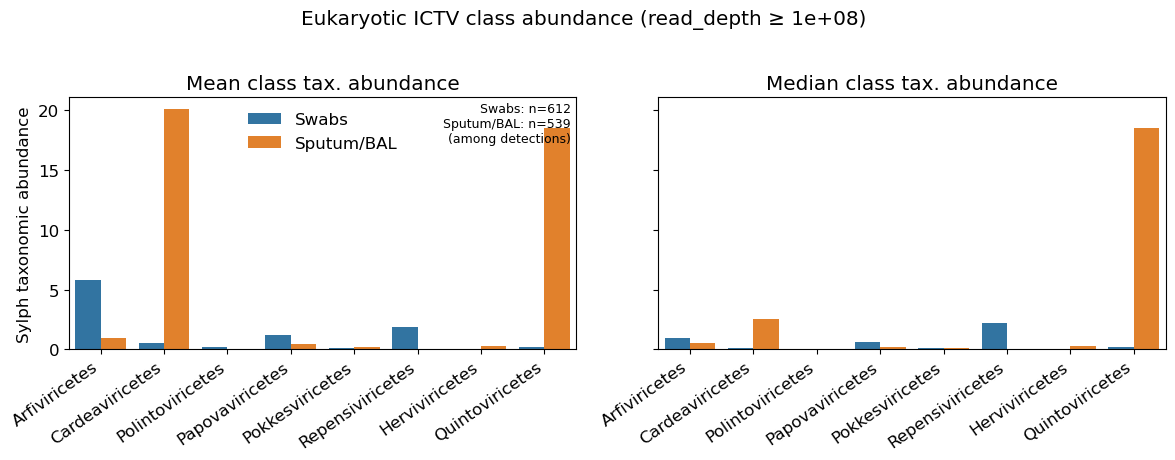

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results/cf_activity_euk_ictv_class_abundance_by_airway.png


airway_label,ictv_class,n_samples_detected,mean_tax_abund,median_tax_abund
str,str,u32,f64,f64
"""Sputum/BAL""","""Cardeaviricetes""",19,20.083937,2.5348
"""Sputum/BAL""","""Quintoviricetes""",1,18.5386,18.5386
"""Sputum/BAL""","""Arfiviricetes""",124,0.973061,0.5373
"""Sputum/BAL""","""Papovaviricetes""",8,0.453063,0.23025
"""Sputum/BAL""","""Herviviricetes""",2,0.25735,0.25735
…,…,…,…,…
"""Swabs""","""Papovaviricetes""",5,1.21378,0.6382
"""Swabs""","""Cardeaviricetes""",11,0.522127,0.1061
"""Swabs""","""Polintoviricetes""",19,0.224379,0.0262


In [80]:
### Eukaryotic ICTV class mean/median relative abundance by sample type
# Relative abundance = Sylph Taxonomic_abundance (tax_abund), summed over eukaryotic
# species within each ICTV class per sample.
# Mean/median are over deep samples where the class is detected (class tax_abund > 0).
# Same cohort as the prevalence plot (read_depth >= 1e8; Swabs vs Sputum/BAL).
# Classes shown = same top-by-prevalence set as the previous cell.

DEPTH_MIN = 1e8

if "euk_detections" not in globals() or "sp_euk_meta" not in globals():
    raise RuntimeError("Run the eukaryotic virus prevalence cell first")
if "_prof_sp" not in globals():
    raise RuntimeError("Run the sylph UHVDB profile cell first to build _prof_sp")
if "euk_class_prevalence" not in globals() or "top_classes" not in globals():
    raise RuntimeError("Run the eukaryotic ICTV class prevalence cell first")

if "read_depth" not in globals():
    read_depth = (
        pl.read_csv(FIG_5 / "cf_metag_read_depth.txt.gz", separator="\t", has_header=False)
        .rename({"column_1": "sample_id", "column_2": "read_depth"})
    )

if "airway_labels" not in globals():
    airway_labels = (
        pl.read_csv(OUT_DIR / "cf_sample_type_airway3.tsv", separator="\t")
        .select(["sample_id", "airway_category"])
        .unique("sample_id")
    )

airway_order = ["Swabs", "Sputum/BAL"]
deep_samples = (
    coverm_df.select("sample_id")
    .unique()
    .join(read_depth, on="sample_id", how="left")
    .join(airway_labels, on="sample_id", how="left")
    .filter(pl.col("read_depth") >= DEPTH_MIN)
    .filter(pl.col("airway_category").is_in(["upper_airway", "lower_airway"]))
    .with_columns(
        pl.col("airway_category")
        .replace({"upper_airway": "Swabs", "lower_airway": "Sputum/BAL"})
        .alias("airway_label")
    )
)

airway_n = {
    str(r["airway_label"]): int(r["n"])
    for r in deep_samples.group_by("airway_label").agg(pl.len().alias("n")).iter_rows(named=True)
}

euk_species_ids = sp_euk_meta.select("species_cluster_id").unique()

# Per-sample class relative abundance (sum tax_abund of euk species in class)
class_abund_sample = (
    _prof_sp.select(["sample_id", "species_cluster_id", "tax_abund"])
    .join(euk_species_ids, on="species_cluster_id", how="inner")
    .join(
        sp_euk_meta.select(["species_cluster_id", "ictv_class"]),
        on="species_cluster_id",
        how="left",
    )
    .filter(pl.col("ictv_class").is_not_null() & (pl.col("tax_abund") > 0))
    .join(deep_samples.select(["sample_id", "airway_label"]), on="sample_id", how="inner")
    .group_by(["sample_id", "airway_label", "ictv_class"])
    .agg(pl.col("tax_abund").sum().alias("class_tax_abund"))
)

euk_class_abund_stats = (
    class_abund_sample.group_by(["airway_label", "ictv_class"])
    .agg(
        [
            pl.len().alias("n_samples_detected"),
            pl.col("class_tax_abund").mean().alias("mean_tax_abund"),
            pl.col("class_tax_abund").median().alias("median_tax_abund"),
        ]
    )
    .sort(["airway_label", "mean_tax_abund"], descending=[False, True])
)

print("Class tax_abund mean/median among detections (deep samples):")
print(
    euk_class_abund_stats.filter(pl.col("ictv_class").is_in(top_classes)).sort(
        ["ictv_class", "airway_label"]
    )
)

plot_long = (
    euk_class_abund_stats.filter(pl.col("ictv_class").is_in(top_classes))
    .unpivot(
        index=["airway_label", "ictv_class", "n_samples_detected"],
        on=["mean_tax_abund", "median_tax_abund"],
        variable_name="stat",
        value_name="tax_abund",
    )
    .with_columns(
        pl.col("stat").replace(
            {"mean_tax_abund": "Mean", "median_tax_abund": "Median"}
        )
    )
    .to_pandas()
)
plot_long["ictv_class"] = pd.Categorical(
    plot_long["ictv_class"], categories=top_classes, ordered=True
)
plot_long["airway_label"] = pd.Categorical(
    plot_long["airway_label"], categories=airway_order, ordered=True
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
palette = {"Swabs": "#1f77b4", "Sputum/BAL": "#ff7f0e"}
for ax, stat in zip(axes, ["Mean", "Median"]):
    sns.barplot(
        data=plot_long[plot_long["stat"] == stat],
        x="ictv_class",
        y="tax_abund",
        hue="airway_label",
        hue_order=airway_order,
        palette=palette,
        ax=ax,
    )
    ax.set_title(f"{stat} class tax. abundance")
    ax.set_xlabel("")
    ax.set_ylabel("Sylph taxonomic abundance" if stat == "Mean" else "")
    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    if stat == "Mean":
        ax.legend(title="", frameon=False)
    else:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

axes[0].text(
    0.99,
    0.98,
    "\n".join([f"{a}: n={airway_n.get(a, 0)}" for a in airway_order])
    + "\n(among detections)",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    fontsize=9,
)
fig.suptitle(
    f"Eukaryotic ICTV class abundance (read_depth ≥ {DEPTH_MIN:.0e})",
    y=1.02,
)
fig.tight_layout()

euk_class_abund_png = OUT_DIR / "cf_activity_euk_ictv_class_abundance_by_airway.png"
fig.savefig(euk_class_abund_png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", euk_class_abund_png)
euk_class_abund_stats.filter(pl.col("ictv_class").is_in(top_classes))


In [223]:
### CF pathogen prevalence: sputum vs non-sputum by relative-abundance threshold
# Same pathogen set and sample_type split as the histogram cells above.
# Denominator = CoverM samples present in figure_6/cf_longitudinal_samplesheet.csv.
# "Any CF pathogen" = max relative abundance across the six pathogen groups.
# Threshold 0 is reported as detected (> 0%), since ≥ 0% is all samples.

from typing import Any

SHEET = FIG_5.parent / "figure_6" / "cf_longitudinal_samplesheet.csv"
SPUTUM_TYPES = ["sputum", "BAL", "bronchoalveolar lavage", "SP"]
THRESHOLDS = [0, 1, 2, 5, 10, 20]

if "sylph_tax" not in globals():
    sylph_tax = pl.read_csv(FIG_5 / "cf_metag_sylph_tax_results.tsv.gz", separator="\t")
if "coverm_samples" not in globals():
    coverm_samples = coverm_df["sample_id"].unique().to_list()

sheet = pl.read_csv(SHEET)
coverm_set = set(coverm_samples)
sputum_samples = set(
    sheet.filter(pl.col("sample_type").is_in(SPUTUM_TYPES))["sample"].to_list()
) & coverm_set
non_sputum_samples = set(
    sheet.filter(~pl.col("sample_type").is_in(SPUTUM_TYPES))["sample"].to_list()
) & coverm_set

pathogen_filter = (
    pl.col("clade_name").str.contains(r"s__Pseudomonas aeruginosa$")
    | pl.col("clade_name").str.contains(r"s__Staphylococcus aureus$")
    | pl.col("clade_name").str.contains(r"s__Haemophilus influenzae$")
    | pl.col("clade_name").str.contains(r"g__Achromobacter")
    | pl.col("clade_name").str.contains(r"g__Stenotrophomonas")
    | pl.col("clade_name").str.contains(r"g__Burkholderia")
)

max_cf_rel = (
    sylph_tax.filter(pl.col("sample_id").is_in(list(coverm_set)))
    .filter(pl.col("clade_name").str.starts_with("d__Bacteria"))
    .filter(pathogen_filter)
    .filter(pl.col("clade_name").str.contains(r"s__"))
    .filter(~pl.col("clade_name").str.contains(r"t__"))
    .with_columns(
        pl.col("clade_name").str.extract(r"g__([^;|]+)", 1).alias("pathogen")
    )
    .group_by(["sample_id", "pathogen"])
    .agg(pl.col("relative_abundance").sum().alias("rel"))
    .group_by("sample_id")
    .agg(pl.col("rel").max().alias("max_cf_rel"))
)


def prevalence_at_threshold(samples: set[Any], thr: float) -> dict:
    base = (
        pl.DataFrame({"sample_id": list(samples)})
        .join(max_cf_rel, on="sample_id", how="left")
        .with_columns(pl.col("max_cf_rel").fill_null(0.0))
    )
    n = base.height
    if thr == 0:
        hit = int((base["max_cf_rel"] > 0).sum())
        threshold_label = "> 0%"
    else:
        hit = int((base["max_cf_rel"] >= thr).sum())
        threshold_label = f"≥ {thr:g}%"
    return {
        "threshold": threshold_label,
        "n": n,
        "n_with_pathogen": hit,
        "percent": 100.0 * hit / n if n else float("nan"),
    }


rows = []
for thr in THRESHOLDS:
    ns = prevalence_at_threshold(non_sputum_samples, thr)
    sp = prevalence_at_threshold(sputum_samples, thr)
    rows.append(
        {
            "threshold": ns["threshold"],
            "non_sputum_percent": ns["percent"],
            "non_sputum_n": f"{ns['n_with_pathogen']}/{ns['n']}",
            "sputum_percent": sp["percent"],
            "sputum_n": f"{sp['n_with_pathogen']}/{sp['n']}",
        }
    )

cf_pathogen_by_sample_type = pl.DataFrame(rows)
print(
    f"CoverM ∩ longitudinal sheet: non-sputum={len(non_sputum_samples):,}, "
    f"sputum={len(sputum_samples):,} "
    f"(sputum types={SPUTUM_TYPES})"
)
print(
    f"CoverM samples not in sheet: "
    f"{len(coverm_set - sputum_samples - non_sputum_samples):,}"
)
print(cf_pathogen_by_sample_type)
cf_pathogen_by_sample_type


CoverM ∩ longitudinal sheet: non-sputum=714, sputum=425 (sputum types=['sputum', 'BAL', 'bronchoalveolar lavage', 'SP'])
CoverM samples not in sheet: 670
shape: (6, 5)
┌───────────┬────────────────────┬──────────────┬────────────────┬──────────┐
│ threshold ┆ non_sputum_percent ┆ non_sputum_n ┆ sputum_percent ┆ sputum_n │
│ ---       ┆ ---                ┆ ---          ┆ ---            ┆ ---      │
│ str       ┆ f64                ┆ str          ┆ f64            ┆ str      │
╞═══════════╪════════════════════╪══════════════╪════════════════╪══════════╡
│ > 0%      ┆ 32.492997          ┆ 232/714      ┆ 94.117647      ┆ 400/425  │
│ ≥ 1%      ┆ 13.865546          ┆ 99/714       ┆ 83.764706      ┆ 356/425  │
│ ≥ 2%      ┆ 10.784314          ┆ 77/714       ┆ 78.588235      ┆ 334/425  │
│ ≥ 5%      ┆ 7.142857           ┆ 51/714       ┆ 70.823529      ┆ 301/425  │
│ ≥ 10%     ┆ 4.901961           ┆ 35/714       ┆ 62.117647      ┆ 264/425  │
│ ≥ 20%     ┆ 3.081232           ┆ 22/714       ┆ 53

threshold,non_sputum_percent,non_sputum_n,sputum_percent,sputum_n
str,f64,str,f64,str
"""> 0%""",32.492997,"""232/714""",94.117647,"""400/425"""
"""≥ 1%""",13.865546,"""99/714""",83.764706,"""356/425"""
"""≥ 2%""",10.784314,"""77/714""",78.588235,"""334/425"""
"""≥ 5%""",7.142857,"""51/714""",70.823529,"""301/425"""
"""≥ 10%""",4.901961,"""35/714""",62.117647,"""264/425"""
"""≥ 20%""",3.081232,"""22/714""",53.176471,"""226/425"""



===== All Pseudomonas-host phages =====
Pseudo≥1% with ≥1 matching phage (host>0): n=411  dominated=148  present-only=263
Max PTH median: dominated=1.634  present-only=1.890  MWU p=0.000499
criterion                                    n  n_dom  dom_rate       OR          p
----------------------------------------------------------------------------------
max PTH ≥ 1.0                              395    142    35.9%     0.94          1
max PTH < 1.0 (only low)                    16      6    37.5%

max PTH ≥ 2.0                              162     42    25.9%     0.47   0.000738
max PTH < 2.0 (only low)                   249    106    42.6%

max PTH ≥ 3.0                               79     10    12.7%      0.2   4.77e-07
max PTH < 3.0 (only low)                   332    138    41.6%

max PTH ≥ 5.0                               27      3    11.1%     0.21    0.00592
max PTH < 5.0 (only low)                   384    145    37.8%


===== Caudoviricetes only =====
Pseudo≥1% with ≥1 mat

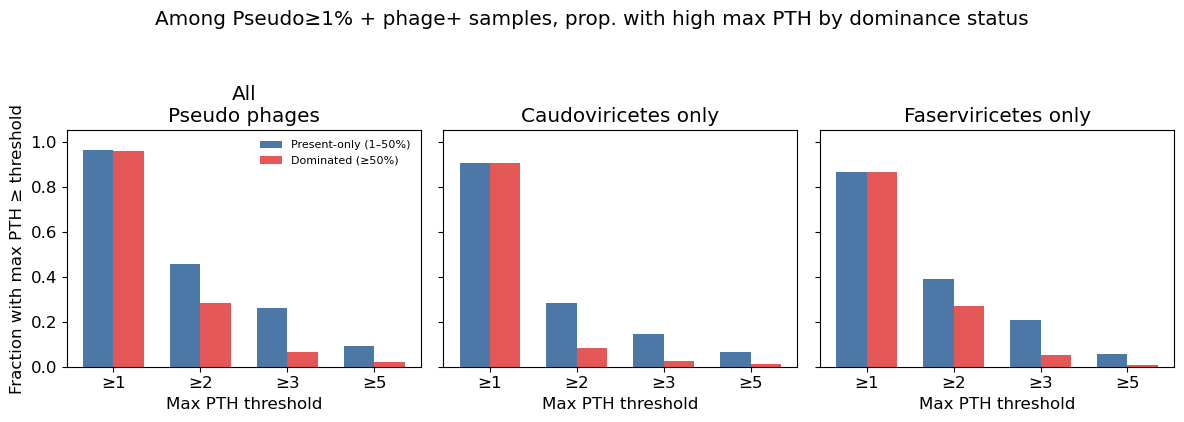

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results/cf_pseudomonas_max_pth_vs_dominance.png


phage_set,threshold,n_high,n_dom_high,dom_rate_high,n_low,n_dom_low,dom_rate_low,odds_ratio,pvalue,frac_dom_with_high_pth,frac_pres_with_high_pth,median_max_pth_dominated,median_max_pth_present_only
str,f64,i64,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64
"""All Pseudomonas-host phages""",1.0,395,142,0.359494,16,6,0.375,0.935441,1.0,0.959459,0.961977,1.634288,1.889892
"""All Pseudomonas-host phages""",2.0,162,42,0.259259,249,106,0.425703,0.47217,0.000738,0.283784,0.456274,1.634288,1.889892
"""All Pseudomonas-host phages""",3.0,79,10,0.126582,332,138,0.415663,0.203739,4.7679e-7,0.067568,0.262357,1.634288,1.889892
"""All Pseudomonas-host phages""",5.0,27,3,0.111111,384,145,0.377604,0.206034,0.00592,0.02027,0.091255,1.634288,1.889892
"""Caudoviricetes only""",1.0,355,133,0.374648,37,14,0.378378,0.984234,1.0,0.904762,0.906122,1.252804,1.472439
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Caudoviricetes only""",5.0,18,2,0.111111,374,145,0.387701,0.197414,0.022479,0.013605,0.065306,1.252804,1.472439
"""Faserviricetes only""",1.0,283,103,0.363958,44,16,0.363636,1.001389,1.0,0.865546,0.865385,1.506532,1.716324
"""Faserviricetes only""",2.0,113,32,0.283186,214,87,0.406542,0.576699,0.029926,0.268908,0.389423,1.506532,1.716324


In [227]:
### Pseudomonas max PTH vs dominance (presence ≥1%)
# Among samples with P. aeruginosa relative abundance ≥ 1% and ≥1 Pseudomonas-host
# phage (CoverM), ask whether high max phage-to-host ratio (PTH) associates with
# dominance (rel ≥ 50%) vs presence-only (1–50%).
# PTH = Sylph virus tax abund / Pseudomonas genus tax abund (host > 0).
# Max PTH = maximum over detected Pseudomonas-host phages in the sample.
# Run for: all classes, Caudoviricetes only, Faserviricetes only.
# Thresholds: max PTH ≥ 1, 2, 3, 5.

from scipy import stats

PRESENCE_THR = 1.0
DOMINANCE_THR = 50.0
PTH_THRESHOLDS = [1.0, 2.0, 3.0, 5.0]

if "sylph_tax" not in globals():
    sylph_tax = pl.read_csv(FIG_5 / "cf_metag_sylph_tax_results.tsv.gz", separator="\t")
if "coverm_samples" not in globals():
    coverm_samples = coverm_df["sample_id"].unique().to_list()

# P. aeruginosa relative abundance
pa_rel = (
    sylph_tax.filter(pl.col("sample_id").is_in(coverm_samples))
    .filter(pl.col("clade_name").str.contains(r"s__Pseudomonas aeruginosa$"))
    .group_by("sample_id")
    .agg(pl.col("relative_abundance").sum().alias("pa_rel"))
)
pa_status = (
    pl.DataFrame({"sample_id": coverm_samples})
    .join(pa_rel, on="sample_id", how="left")
    .with_columns(pl.col("pa_rel").fill_null(0.0))
    .with_columns(
        [
            (pl.col("pa_rel") >= PRESENCE_THR).alias("present"),
            (pl.col("pa_rel") >= DOMINANCE_THR).alias("dominated"),
        ]
    )
)

# Pseudomonas genus taxonomic abundance (PTH denominator)
host_abund = (
    sylph_tax.filter(pl.col("sample_id").is_in(coverm_samples))
    .filter(pl.col("clade_name").str.starts_with("d__Bacteria"))
    .filter(pl.col("clade_name").str.contains(r"s__"))
    .filter(~pl.col("clade_name").str.contains(r"t__"))
    .filter(pl.col("clade_name").str.contains(r"g__Pseudomonas"))
    .group_by("sample_id")
    .agg(pl.col("taxonomic_abundance").sum().alias("host_abund"))
)

# Virus species metadata
if "sp_meta" not in globals():
    sp_meta = (
        uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep"))
        .select(
            [
                "species_cluster_id",
                "genus_cluster_id",
                "family_cluster_id",
                "ictv_class",
                "final_host_pred",
            ]
        )
        .unique("species_cluster_id")
        .with_columns(
            [
                pl.col("species_cluster_id").cast(pl.Int64),
                pl.col("final_host_pred").cast(pl.Utf8).fill_null(""),
            ]
        )
    )

pseudo_sp_meta = sp_meta.filter(pl.col("final_host_pred").str.contains("Pseudomonas"))

# CoverM detections of Pseudomonas-host species
pseudo_det = (
    coverm_df.filter(pl.col("breadth_ratio") > 0)
    .join(_id_ictv, left_on="contig_id", right_on="uhvdb_id", how="left")
    .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .join(
        pseudo_sp_meta.select(["species_cluster_id", "ictv_class"]),
        on="species_cluster_id",
        how="inner",
    )
    .unique(["sample_id", "species_cluster_id"])
    .select(["sample_id", "species_cluster_id", "ictv_class"])
)

# Sylph virus taxonomic abundance
virus_abund = (
    sylph_tax.filter(pl.col("sample_id").is_in(coverm_samples))
    .filter(pl.col("clade_name").str.contains(r"vSPECIES"))
    .with_columns(
        pl.col("clade_name")
        .str.extract(r"vSPECIES-(\d+)", 1)
        .cast(pl.Int64)
        .alias("species_cluster_id")
    )
    .filter(
        pl.col("species_cluster_id").is_in(
            pseudo_sp_meta["species_cluster_id"].to_list()
        )
    )
    .select(
        [
            "sample_id",
            "species_cluster_id",
            pl.col("taxonomic_abundance").alias("virus_abund"),
        ]
    )
)

phage_pth = (
    pseudo_det.join(virus_abund, on=["sample_id", "species_cluster_id"], how="left")
    .join(host_abund, on="sample_id", how="left")
    .with_columns(
        [
            pl.col("virus_abund").fill_null(0.0),
            pl.col("host_abund").fill_null(0.0),
        ]
    )
    .filter(pl.col("host_abund") > 0)
    .with_columns((pl.col("virus_abund") / pl.col("host_abund")).alias("pth"))
)


def sample_max_pth(phage_subset: pl.DataFrame) -> pl.DataFrame:
    return (
        phage_subset.group_by("sample_id")
        .agg(
            [
                pl.col("pth").max().alias("max_pth"),
                pl.col("pth").median().alias("median_pth"),
                pl.len().alias("n_phages"),
            ]
        )
        .join(pa_status, on="sample_id", how="inner")
        .filter(pl.col("present"))
        .with_columns(
            ((pl.col("pa_rel") >= PRESENCE_THR) & (pl.col("pa_rel") < DOMINANCE_THR))
            .alias("present_only")
        )
    )


def summarize_pth_vs_dominance(sample_pth: pl.DataFrame, label: str) -> pl.DataFrame:
    print(f"\n===== {label} =====")
    print(
        f"Pseudo≥{PRESENCE_THR:g}% with ≥1 matching phage (host>0): n={sample_pth.height:,}  "
        f"dominated={int(sample_pth['dominated'].sum()):,}  "
        f"present-only={int(sample_pth['present_only'].sum()):,}"
    )
    dom = sample_pth.filter(pl.col("dominated"))
    pres = sample_pth.filter(pl.col("present_only"))
    if dom.height and pres.height:
        u, p = stats.mannwhitneyu(
            dom["max_pth"].to_numpy(),
            pres["max_pth"].to_numpy(),
            alternative="two-sided",
        )
        print(
            f"Max PTH median: dominated={dom['max_pth'].median():.3f}  "
            f"present-only={pres['max_pth'].median():.3f}  MWU p={p:.3g}"
        )

    rows = []
    print(
        f"{'criterion':40s} {'n':>5s} {'n_dom':>6s} {'dom_rate':>9s} {'OR':>8s} {'p':>10s}"
    )
    print("-" * 82)
    for thr in PTH_THRESHOLDS:
        hi = sample_pth.filter(pl.col("max_pth") >= thr)
        lo = sample_pth.filter(pl.col("max_pth") < thr)
        if hi.height == 0 or lo.height == 0:
            print(f"max PTH ≥ {thr:g}: hi={hi.height}, lo={lo.height} — skip")
            continue
        a = int(hi["dominated"].sum())
        b = hi.height - a
        c = int(lo["dominated"].sum())
        d = lo.height - c
        oddsratio, pval = stats.fisher_exact([[a, b], [c, d]], alternative="two-sided")
        print(
            f"{'max PTH ≥ '+str(thr):40s} {hi.height:5d} {a:6d} {a/hi.height:8.1%} "
            f"{oddsratio:8.2g} {pval:10.3g}"
        )
        print(
            f"{'max PTH < '+str(thr)+' (only low)':40s} {lo.height:5d} {c:6d} {c/lo.height:8.1%}"
        )
        rows.append(
            {
                "phage_set": label,
                "threshold": thr,
                "n_high": hi.height,
                "n_dom_high": a,
                "dom_rate_high": a / hi.height,
                "n_low": lo.height,
                "n_dom_low": c,
                "dom_rate_low": c / lo.height,
                "odds_ratio": float(oddsratio)
                if np.isfinite(oddsratio)
                else float("inf"),
                "pvalue": float(pval),
                "frac_dom_with_high_pth": float((dom["max_pth"] >= thr).mean())
                if dom.height
                else float("nan"),
                "frac_pres_with_high_pth": float((pres["max_pth"] >= thr).mean())
                if pres.height
                else float("nan"),
                "median_max_pth_dominated": float(dom["max_pth"].median())
                if dom.height
                else float("nan"),
                "median_max_pth_present_only": float(pres["max_pth"].median())
                if pres.height
                else float("nan"),
            }
        )
        print()
    return pl.DataFrame(rows), sample_pth


sets = {
    "All Pseudomonas-host phages": phage_pth,
    "Caudoviricetes only": phage_pth.filter(pl.col("ictv_class") == "Caudoviricetes"),
    "Faserviricetes only": phage_pth.filter(pl.col("ictv_class") == "Faserviricetes"),
}

summary_parts = []
sample_tables = {}
for label, subset in sets.items():
    sample_pth = sample_max_pth(subset)
    summ, sample_tables[label] = summarize_pth_vs_dominance(sample_pth, label)
    if summ.height:
        summary_parts.append(summ)

pseudo_pth_dominance_summary = (
    pl.concat(summary_parts) if summary_parts else pl.DataFrame()
)
print("\nSummary table:")
print(pseudo_pth_dominance_summary)

out_tsv = OUT_DIR / "cf_pseudomonas_max_pth_vs_dominance.tsv.gz"
pseudo_pth_dominance_summary.write_csv(out_tsv, separator="\t", compression="gzip")
print("Saved", out_tsv)

# Bar plot: among present-only vs dominated, fraction with max PTH ≥ threshold
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, label in zip(axes, sets.keys()):
    sub = pseudo_pth_dominance_summary.filter(pl.col("phage_set") == label)
    if sub.height == 0:
        ax.set_title(label)
        ax.axis("off")
        continue
    x = np.arange(sub.height)
    w = 0.35
    ax.bar(
        x - w / 2,
        sub["frac_pres_with_high_pth"].to_list(),
        w,
        label="Present-only (1–50%)",
        color="#4C78A8",
    )
    ax.bar(
        x + w / 2,
        sub["frac_dom_with_high_pth"].to_list(),
        w,
        label="Dominated (≥50%)",
        color="#E45756",
    )
    ax.set_xticks(x)
    ax.set_xticklabels([f"≥{t:g}" for t in sub["threshold"].to_list()])
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Max PTH threshold")
    ax.set_title(label.replace(" Pseudomonas-host phages", "\nPseudo phages"))
    if ax is axes[0]:
        ax.set_ylabel("Fraction with max PTH ≥ threshold")
        ax.legend(frameon=False, fontsize=8)
fig.suptitle(
    f"Among Pseudo≥{PRESENCE_THR:g}% + phage+ samples, "
    f"prop. with high max PTH by dominance status",
    y=1.05,
)
fig.tight_layout()
png = OUT_DIR / "cf_pseudomonas_max_pth_vs_dominance.png"
fig.savefig(png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", png)

pseudo_pth_dominance_summary
